IMPORTACIONES Y CARGA DE DATOS
--------

In [62]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

import holidays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer #agregado
from sklearn.pipeline import Pipeline #agregado
from sklearn.model_selection import KFold, cross_val_score #agregado
from sklearn.pipeline import make_pipeline #agregado
from sklearn.compose import ColumnTransformer #agregado

In [63]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [64]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [65]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

EDA
--------


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


#### Análisis sobre variables de coordenadas: pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude

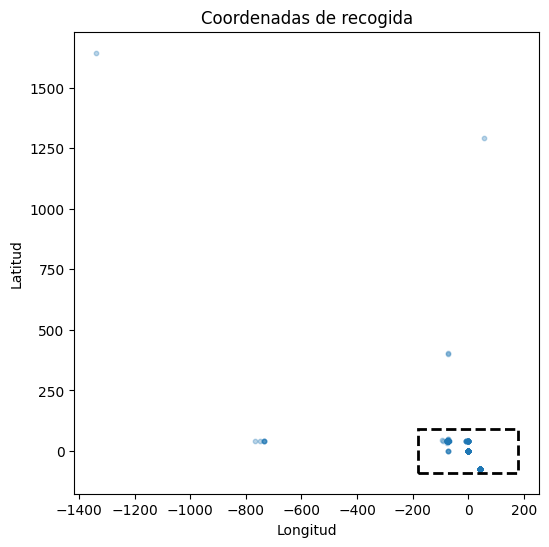

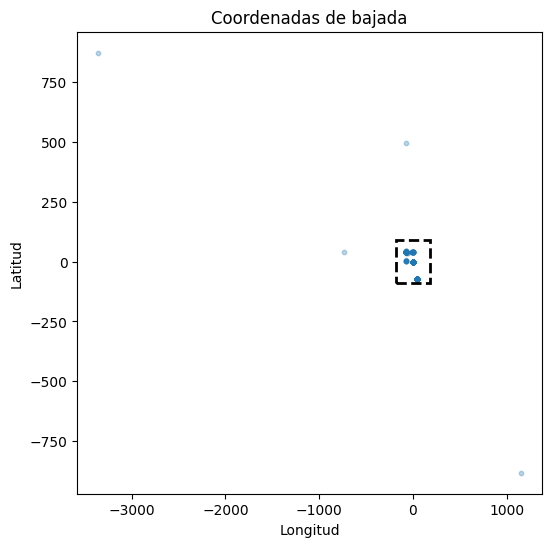

In [67]:
#Coordenadas de Pickup
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=10, alpha=0.3)

#Rectángulo que representa las coordenadas validas del mundo
world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida")
plt.show()

#Coordenadas de Dropoff
plt.figure(figsize=(6,6))
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=10, alpha=0.3)

#Rectángulo que representa las coordenadas validas del mundo
world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de bajada")
plt.show()


In [68]:
#Coordenadas reales
lat_min, lat_max = -90, 90  
lon_min, lon_max = -180, 180

valid_pickup_lat = df["pickup_latitude"].between(lat_min, lat_max)
valid_pickup_lon = df["pickup_longitude"].between(lon_min, lon_max)
valid_dropoff_lat = df["dropoff_latitude"].between(lat_min, lat_max)
valid_dropoff_lon = df["dropoff_longitude"].between(lon_min, lon_max)

invalid_counts = (
    (~valid_pickup_lat).astype(int) +
    (~valid_pickup_lon).astype(int) +
    (~valid_dropoff_lat).astype(int) +
    (~valid_dropoff_lon).astype(int)
)

#Cantidad de registros con mas de 1 coordenada invalida que no son posible imputar
df_invalidos = df[invalid_counts > 1]
print('---Registros con más de 1 coordenada inválida---')
print(f'Cantidad: {df_invalidos.shape[0]}')
print(f'Porcentaje respecto al dataFrame completo: {(df_invalidos.shape[0]/df.shape[0])*100}%')

---Registros con más de 1 coordenada inválida---
Cantidad: 3
Porcentaje respecto al dataFrame completo: 0.0015%


In [69]:
#Dropeamos registros con más de 1 coordenada inválida
df_filtrado = df[invalid_counts <= 1]

In [70]:
#Reemplazamos las coordenadas inválidas con NaN
df_filtrado.loc[~valid_pickup_lat, "pickup_latitude"] = np.nan
df_filtrado.loc[~valid_pickup_lon, "pickup_longitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lat, "dropoff_latitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lon, "dropoff_longitude"] = np.nan

#Cantidad de registros reemplazados con NaN
print(f'Cantidad total de registros reemplazados con NaN: {df_filtrado.isna().sum().sum()}')
df_filtrado.isna().sum()

Cantidad total de registros reemplazados con NaN: 10


key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     6
pickup_latitude      2
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

#### Análisis sobre fare_amount

Cantidad de valores nulos en fare_amount: 0
Cantidad de valores NaN en fare_amount: 0
Cantidad de valores cero y negativos en fare_amount: 22
Porcentaje de valores cero y negativos sobre el total de registros en fare_amount: 0.011000165002475037%


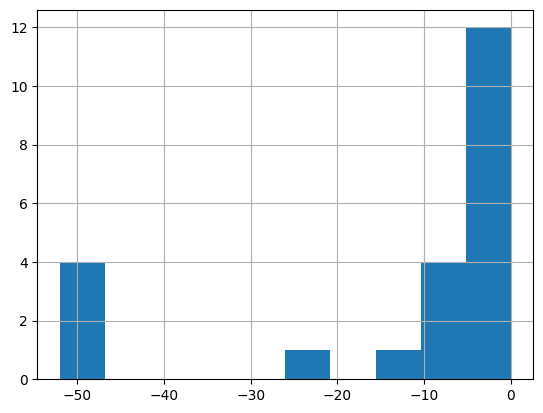

In [71]:
fare_amount_null = df_filtrado['fare_amount'].isnull().sum() #no hay nulos en fare_amount
fare_amount_na = df_filtrado['fare_amount'].isna().sum() #no hay nulos en fare_amount
print(f'Cantidad de valores nulos en fare_amount: {fare_amount_null}')
print(f'Cantidad de valores NaN en fare_amount: {fare_amount_na}')

df_filtrado[df_filtrado["fare_amount"] <= 0]["fare_amount"].hist()
negativos = df_filtrado[df_filtrado["fare_amount"] <= 0]['fare_amount'].size
print(f"Cantidad de valores cero y negativos en fare_amount: {negativos}")
print(f"Porcentaje de valores cero y negativos sobre el total de registros en fare_amount: {negativos / df_filtrado.fare_amount.size * 100}%")  # porcentaje de negativos en fare_amount

In [72]:
# eliminamos valores negativos y ceros en fare_amount
df_filtrado = df_filtrado[df_filtrado['fare_amount'] > 0]  

#### Función haversine_km para cálculo de distancias de cada viaje

In [73]:
def haversine_km(lat1, lon1, lat2, lon2):
    # retorna distancia en kilómetros (vectorizado)
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


df_filtrado['distance_km'] = haversine_km(
    df_filtrado['pickup_latitude'], df_filtrado['pickup_longitude'],
    df_filtrado['dropoff_latitude'], df_filtrado['dropoff_longitude']
)

In [74]:
df_filtrado['distance_km'].describe()

count    199965.000000
mean         20.475660
std         378.655684
min           0.000000
25%           1.215335
50%           2.120955
75%           3.874804
max        8782.898606
Name: distance_km, dtype: float64

<Axes: xlabel='distance_km'>

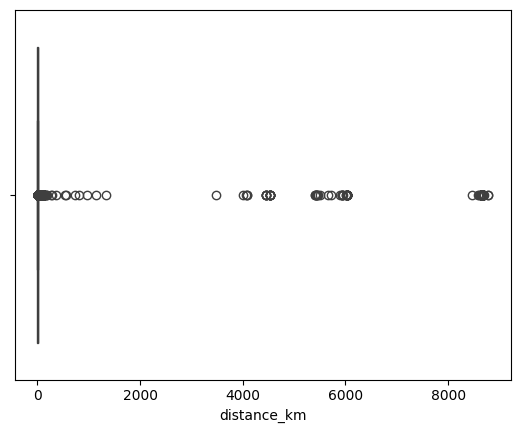

In [75]:
sns.boxplot(x=df_filtrado['distance_km'])

#### Análisis sobre variables de coordenadas para reducir distancias absurdas

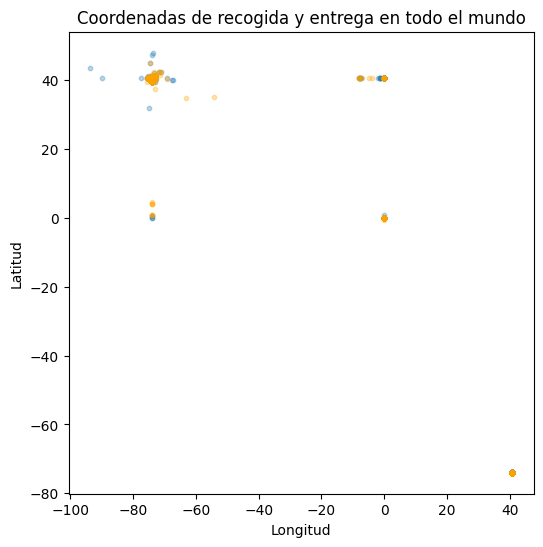

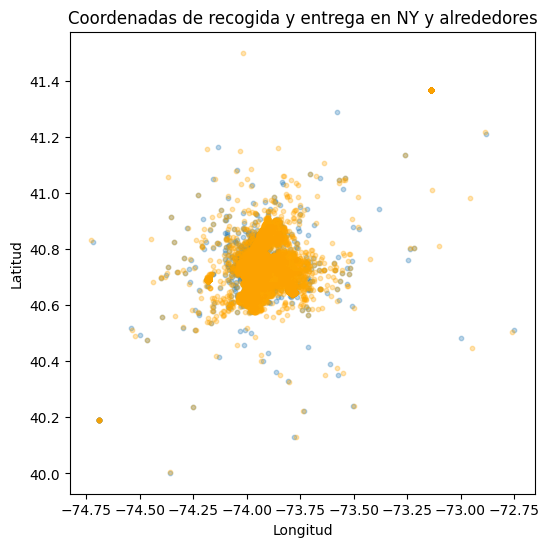

In [76]:
ny_coords = (
    (df_filtrado["pickup_latitude"].between(40, 42)| df_filtrado["pickup_latitude"].isna())&
    (df_filtrado["pickup_longitude"].between(-75, -72) | df_filtrado["pickup_longitude"].isna()) &
    (df_filtrado["dropoff_latitude"].between(40, 42) | df_filtrado["dropoff_latitude"].isna()) &
    (df_filtrado["dropoff_longitude"].between(-75, -72) | df_filtrado["dropoff_longitude"].isna())
)
df_filtrado_ny = df_filtrado[ny_coords].copy()
plt.figure(figsize=(6,6))
plt.scatter(df_filtrado["pickup_longitude"], df_filtrado["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado["dropoff_longitude"], df_filtrado["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en todo el mundo")      
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_filtrado_ny["pickup_longitude"], df_filtrado_ny["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado_ny["dropoff_longitude"], df_filtrado_ny["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en NY y alrededores")      
plt.show()

CREACIÓN DE DUMMIES
-------------------

In [77]:
df_filtrado_ny["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)

df_filtrado_ny["pickup_datetime"] = df_filtrado_ny["pickup_datetime"].dt.tz_convert("America/New_York")

us_holidays = holidays.US(years=df_filtrado_ny["pickup_datetime"].dt.year.unique(), state="NY")

df_filtrado_ny["is_holiday"] = df_filtrado_ny["pickup_datetime"].dt.date.isin(us_holidays).astype(int)


df_filtrado_ny["is_workday"] = (
    (df_filtrado_ny["pickup_datetime"].dt.dayofweek < 4) &  # lunes a jueves
    (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana
).astype(int)

df_filtrado_ny[[ "is_holiday", "is_workday"]].value_counts()

# Extraer hora
df_filtrado_ny["hora_recogida"] = df_filtrado_ny["pickup_datetime"].dt.hour
## Extraer mes
df_filtrado_ny["mes_recogida"] = df_filtrado_ny["pickup_datetime"].dt.month


#creo dummies de turnos (6-12, 12-18, 18-24, 0-6)
df_filtrado_ny["turno_mañana"] = ((df_filtrado_ny["hora_recogida"] >= 6) & (df_filtrado_ny["hora_recogida"] < 12)).astype(int)
df_filtrado_ny["turno_tarde"] = ((df_filtrado_ny["hora_recogida"] >= 12) & (df_filtrado_ny["hora_recogida"] < 18)).astype(int)
df_filtrado_ny["turno_noche"] = ((df_filtrado_ny["hora_recogida"] >= 18) & (df_filtrado_ny["hora_recogida"] < 24)).astype(int)
df_filtrado_ny["turno_madrugada"] = ((df_filtrado_ny["hora_recogida"] >= 0) & (df_filtrado_ny["hora_recogida"] < 6)).astype(int)

#agrupamos meses por estaciones verano, otoño, invierno, primavera

df_filtrado_ny["estacion_verano"] = df_filtrado_ny["mes_recogida"].isin([6,7,8]).astype(int)
df_filtrado_ny["estacion_otoño"] = df_filtrado_ny["mes_recogida"].isin([9,10,11]).astype(int)
df_filtrado_ny["estacion_invierno"] = df_filtrado_ny["mes_recogida"].isin([12,1,2]).astype(int)
df_filtrado_ny["estacion_primavera"] = df_filtrado_ny["mes_recogida"].isin([3,4,5]).astype(int)

### Creamos una nueva variable dummie con el tipo de viaje por pasajero 

df_filtrado_ny["uber_comun"] = df_filtrado_ny["passenger_count"].isin([1, 2, 3, 4]).astype(int)
df_filtrado_ny["uber_grande"] = df_filtrado_ny["passenger_count"].isin([5, 6]).astype(int)

df_modelo = df_filtrado_ny.drop(columns=["key", "hora_recogida", "pickup_datetime", "date", "mes_recogida"])


C:\Users\ACER\AppData\Local\Temp\ipykernel_6536\2635464431.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana


GRÁFICOS DISTRIBUCIONES
-----------------------

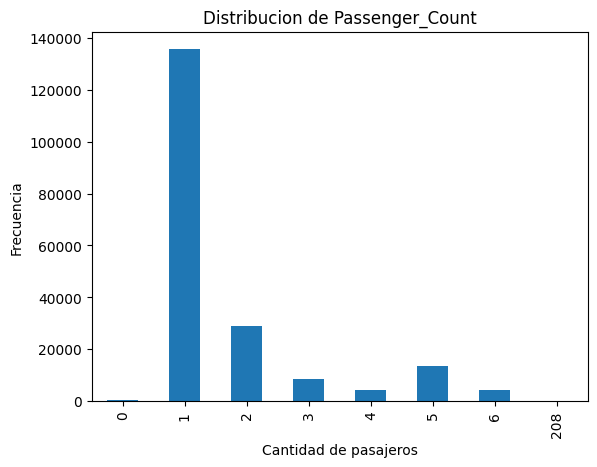

passenger_count
1      135491
2       28835
5       13722
3        8696
6        4184
4        4182
0         686
208         1
Name: count, dtype: int64

In [78]:
df_modelo["passenger_count"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribucion de Passenger_Count")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()
df_modelo["passenger_count"].value_counts()


In [79]:
#Convertimos el valor 208 en nulo 
df_modelo["passenger_count"] = df_modelo["passenger_count"].replace(208, np.nan)

Cantidad de viajes con distancia = 0: 2038

Estadísticas de fare_amount en viajes con distancia = 0:
count    2038.000000
mean       11.101305
std        14.647066
min         2.500000
25%         4.900000
50%         6.500000
75%        10.100000
max       200.000000
Name: fare_amount, dtype: float64


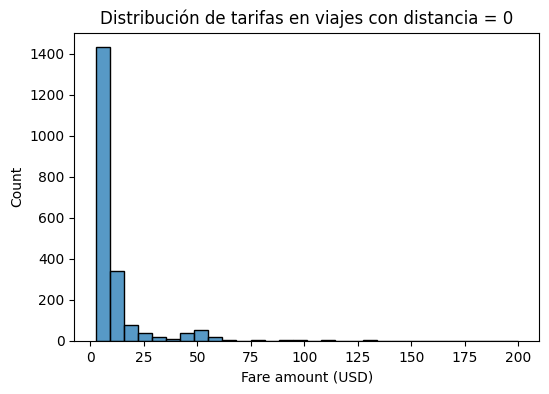

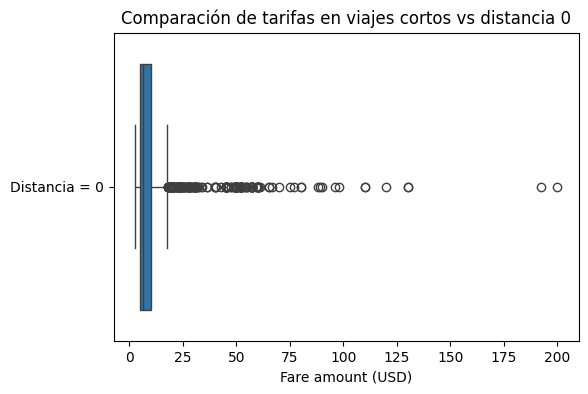

(1012,)

In [80]:
# 1. Contar cuántos viajes tienen distancia 0
zero_dist = df_modelo[df_modelo["distance_km"] == 0]
print("Cantidad de viajes con distancia = 0:", len(zero_dist))

# 2. Describir sus tarifas
print("\nEstadísticas de fare_amount en viajes con distancia = 0:")
print(zero_dist["fare_amount"].describe())

# 3. Histograma de esas tarifas
plt.figure(figsize=(6,4))
sns.histplot(zero_dist["fare_amount"], bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
plt.title("Distribución de tarifas en viajes con distancia = 0")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=[zero_dist["fare_amount"]],
    orient="h"
)
plt.yticks([0], ["Distancia = 0"])
plt.xlabel("Fare amount (USD)")
plt.title("Comparación de tarifas en viajes cortos vs distancia 0")
plt.show()

zero_dist[zero_dist["fare_amount"] > 6.5]["fare_amount"].shape


SPLIT
-----

In [81]:
X_train, X_test, y_train, y_test = train_test_split(df_modelo.drop(columns='fare_amount'), df_modelo['fare_amount'], test_size=0.2, random_state=42)


IMPUTACION DE VALORES FALTANTES EN COORDENADAS Y DISTANCIAS 
--------------------------------------------------------------

In [82]:
coords = ["pickup_latitude","pickup_longitude","dropoff_latitude","dropoff_longitude"]

invalidas = X_train[coords].isna().sum(axis=1)
filas_a_imputar = X_train[invalidas == 1].copy()


scaler = StandardScaler()
X_escaladas_train = scaler.fit_transform(filas_a_imputar[coords])

# Imputación KNN en X_train
imputer = KNNImputer(n_neighbors=5)
X_imputadas_train = imputer.fit_transform(X_escaladas_train)

# 4️⃣ Volvemos a coordenadas originales en X_train
filas_a_imputar[coords] = scaler.inverse_transform(X_imputadas_train)

# 5️⃣ Reintegrar al X_train original
X_train.update(filas_a_imputar)

# 6️⃣ Imputación en X_test usando los mismos scaler e imputador
invalidas_test = X_test[coords].isna().sum(axis=1)
filas_a_imputar_test = X_test[invalidas_test == 1].copy()

# Escalar X_test con scaler ya ajustado
X_escaladas_test = scaler.transform(filas_a_imputar_test[coords])

# Imputar usando imputador ya ajustado
X_imputadas_test = imputer.transform(X_escaladas_test )

# Volvemos a coordenadas originales en X_test
filas_a_imputar_test[coords] = scaler.inverse_transform(X_imputadas_test)

# Reintegrar al X_test original
X_test.update(filas_a_imputar_test)



In [83]:
X_train['distance_km'] = haversine_km(
    X_train['pickup_latitude'], X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude']
)

X_test['distance_km'] = haversine_km(
    X_test['pickup_latitude'], X_test['pickup_longitude'],
    X_test['dropoff_latitude'], X_test['dropoff_longitude']
)
   

### _DROP DE COORDENADAS_

In [84]:
##Dropeamos variables pickup_longitude, pickup_latitude, dropoff_longitude y dropoff_latitude

X_train = X_train.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])
X_test  = X_test.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

df_modelo = df_modelo.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

In [85]:
""""
hora_cols = [col for col in X_train.columns if col.startswith("turno_")]

for col in hora_cols:
    X_train[col] = X_train["distance_km"] * X_train[col]

hora_cols_test = [col for col in X_test.columns if col.startswith("turno_")]

for col in hora_cols_test:
    X_test[col] = X_test["distance_km"] * X_test[col]

print(X_train[hora_cols].head())
print(X_test[hora_cols].head())


#multiplicamos distance_km por las dummies de mes
estacion_cols = [col for col in X_train.columns if col.startswith("estacion_")]  

estacion_cols_test = [col for col in X_test.columns if col.startswith("estacion_")]

for col in estacion_cols:
    X_train[col] = X_train["distance_km"] * X_train[col]
    X_test[col] = X_test["distance_km"] * X_test[col]

    
print(X_train[estacion_cols].head())
"""

'"\nhora_cols = [col for col in X_train.columns if col.startswith("turno_")]\n\nfor col in hora_cols:\n    X_train[col] = X_train["distance_km"] * X_train[col]\n\nhora_cols_test = [col for col in X_test.columns if col.startswith("turno_")]\n\nfor col in hora_cols_test:\n    X_test[col] = X_test["distance_km"] * X_test[col]\n\nprint(X_train[hora_cols].head())\nprint(X_test[hora_cols].head())\n\n\n#multiplicamos distance_km por las dummies de mes\nestacion_cols = [col for col in X_train.columns if col.startswith("estacion_")]  \n\nestacion_cols_test = [col for col in X_test.columns if col.startswith("estacion_")]\n\nfor col in estacion_cols:\n    X_train[col] = X_train["distance_km"] * X_train[col]\n    X_test[col] = X_test["distance_km"] * X_test[col]\n\n    \nprint(X_train[estacion_cols].head())\n'

### _IMPUTACION DE LOS VALORES DE FARE_AMOUNT DE LA DISTANCIA MENOR A 0,1_


In [86]:
# Encontrar la moda SOLO en el train
zero_dist_train = y_train[X_train["distance_km"] < 0.1]
moda_fare_train = zero_dist_train.mode()[0]

# Imputar en train usando esa moda
y_train.loc[X_train["distance_km"] < 0.1] = moda_fare_train


In [87]:
mask_train = X_train["distance_km"] < 0.1
mask_test  = X_test["distance_km"] < 0.1

# Antes de imputar, podés chequear cuántos casos hay:
print("Filas a imputar en train:", mask_train.sum())
print("Filas a imputar en test:", mask_test.sum())

# Aplicás la moda:
y_train.loc[mask_train] = moda_fare_train


Filas a imputar en train: 2533
Filas a imputar en test: 675


In [88]:
print("Valores únicos en train después de imputar:",
      y_train[mask_train].unique())
print("Valores únicos en test después de imputar:",
      y_test[mask_test].unique())

Valores únicos en train después de imputar: [2.5]
Valores únicos en test después de imputar: [  2.5    9.3    5.7    7.7    3.     6.5    2.9    6.9    7.5    3.25
   7.3    8.     6.1    4.1    4.5    3.7   12.5   45.     4.9   15.5
   7.    18.1   32.2   52.    13.     8.9   12.9    5.3   12.    96.
  10.1   11.5   50.    16.5    8.1    5.5   47.7  142.    11.    25.
  17.    10.     3.3   49.57  16.9   26.9    6.    48.     9.7   49.8
  12.1   56.8   95.    13.5   20.5   20.    13.7   17.7    4.    11.7
  50.5   15.7   24.5   14.5   10.5   35.7   11.3    3.5   13.3   17.5
  20.4   38.     5.    23.7   71.     8.5    7.8   15.3    7.4   19.
  14.9   57.33  18.9  110.    40.    75.    28.1   98.    71.5   14.
  19.5   18.     9.5   40.5   14.1   39.    19.8   10.9  113.    16.
  53.    10.3  200.    39.5   66.81  16.1   55.    58.5   20.1   13.2
   8.6  120.    65.     6.3   17.3 ]


In [89]:
y_train[y_train > 300].sort_values(ascending=False)
y_test[y_test > 300].sort_values(ascending=False)

Series([], Name: fare_amount, dtype: float64)

### _RATIO PRECIO/DISTANCIA_


In [90]:
# Aseguramos que y_train sea vector 1D alineado con X_train
y_train = np.array(y_train).reshape(-1)   # fuerza a (n,)
y_train = pd.Series(y_train, index=X_train.index)

# Inicializamos columna
X_train["costo_por_metro"] = np.nan

# Máscara de distancias válidas
mask_train = X_train["distance_km"] >= 0.1

# División elemento a elemento (sin broadcasting raro)
X_train.loc[mask_train, "costo_por_metro"] = (
    y_train[mask_train] / (X_train.loc[mask_train, "distance_km"] * 1000)
)
print(y_train.shape)                # debería ser (137057,)
print(X_train["distance_km"].shape) # también (137057,)



(156637,)
(156637,)


In [91]:
umbral = 0.02

# Máscara de outliers
mask_outliers = X_train["costo_por_metro"] > umbral

# Calcular media de costo_por_km SOLO en los que no son outliers
mean_cpk = X_train.loc[~mask_outliers, "costo_por_metro"].mean()


y_train[mask_outliers] = (
    X_train.loc[mask_outliers, "distance_km"] * mean_cpk
)
#Dropeamos la columna auxiliar
X_train = X_train.drop(columns=["costo_por_metro"])

print("Outliers detectados:", mask_outliers.sum())
print("Media costo/km usada:", mean_cpk)
X_train[mask_outliers]

Outliers detectados: 903
Media costo/km usada: 0.0042825171654250396


,passenger_count,distance_km,is_holiday,is_workday,turno_mañana,turno_tarde,turno_noche,turno_madrugada,estacion_verano,estacion_otoño,estacion_invierno,estacion_primavera,uber_comun,uber_grande
193806,1.0,0.320520,0,1,1,0,0,0,1,0,0,0,1,0
177032,1.0,1.208110,0,1,0,0,1,0,1,0,0,0,1,0
105079,1.0,0.142000,1,0,0,1,0,0,0,1,0,0,1,0
168150,1.0,0.282948,0,0,0,0,1,0,1,0,0,0,1,0
128181,1.0,0.631684,0,1,0,0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143959,1.0,0.252980,0,1,1,0,0,0,0,0,0,1,1,0
44969,4.0,0.244219,0,0,0,0,1,0,0,1,0,0,1,0
185623,2.0,0.257002,0,0,0,1,0,0,0,0,1,0,1,0
101430,1.0,2.927981,0,1,0,1,0,0,0,0,1,0,1,0


IMPUTACION DE PASAJEROS POR LA MODA
-----------------------------------

In [92]:

##imputamos valor nulo de passenger_count por la moda
moda_passenger = X_train["passenger_count"].mode()[0]
X_train["passenger_count"].fillna(moda_passenger, inplace=True)
X_test["passenger_count"].fillna(moda_passenger, inplace=True)  
#Borro passenger_count porque ya tengo las dummies
X_train = X_train.drop(columns=['passenger_count'])
X_test  = X_test.drop(columns=['passenger_count'])
df_modelo = df_modelo.drop(columns=['passenger_count'])

C:\Users\ACER\AppData\Local\Temp\ipykernel_6536\3537679703.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["passenger_count"].fillna(moda_passenger, inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_6536\3537679703.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

## _ESTADÍSTICAS_ 

In [93]:
print("\n--- Estadísticas TRAIN ---")
print(train.describe(include="all").transpose())

print("\n--- Estadísticas TEST ---")
print(test.describe(include="all").transpose())


--- Estadísticas TRAIN ---


NameError: name 'train' is not defined

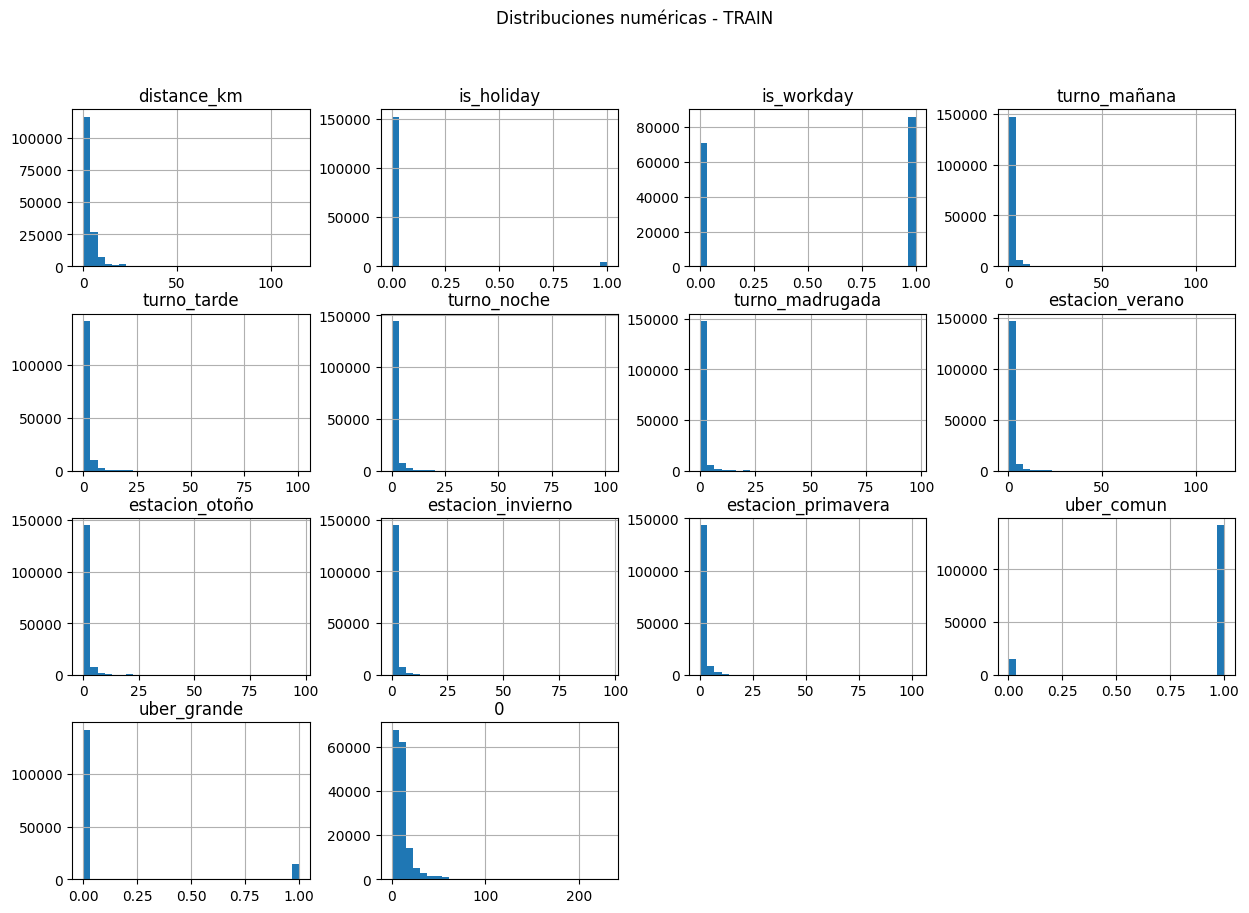

In [ ]:
# Histogramas de variables numéricas
num_cols = train.select_dtypes(include=["int64", "float64"]).columns
train[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribuciones numéricas - TRAIN")
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10288\549040856.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10288\549040856.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


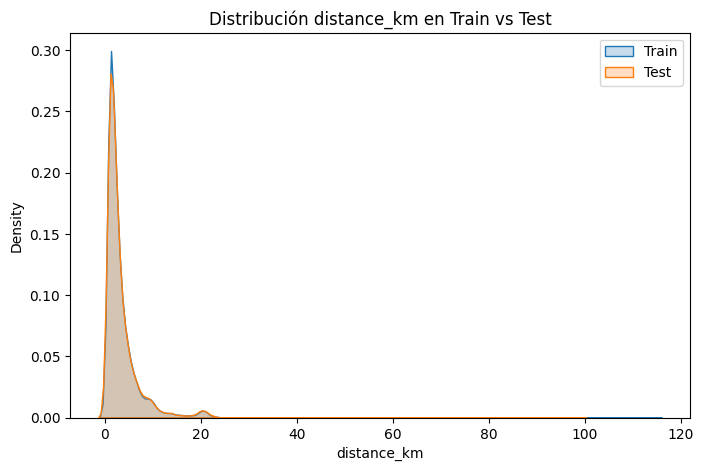

In [ ]:

col = "distance_km"  # ejemplo, podés iterar con varias
plt.figure(figsize=(8,5))
sns.kdeplot(train[col], label="Train", shade=True)
sns.kdeplot(test[col], label="Test", shade=True)
plt.title(f"Distribución {col} en Train vs Test")
plt.legend()
plt.show()

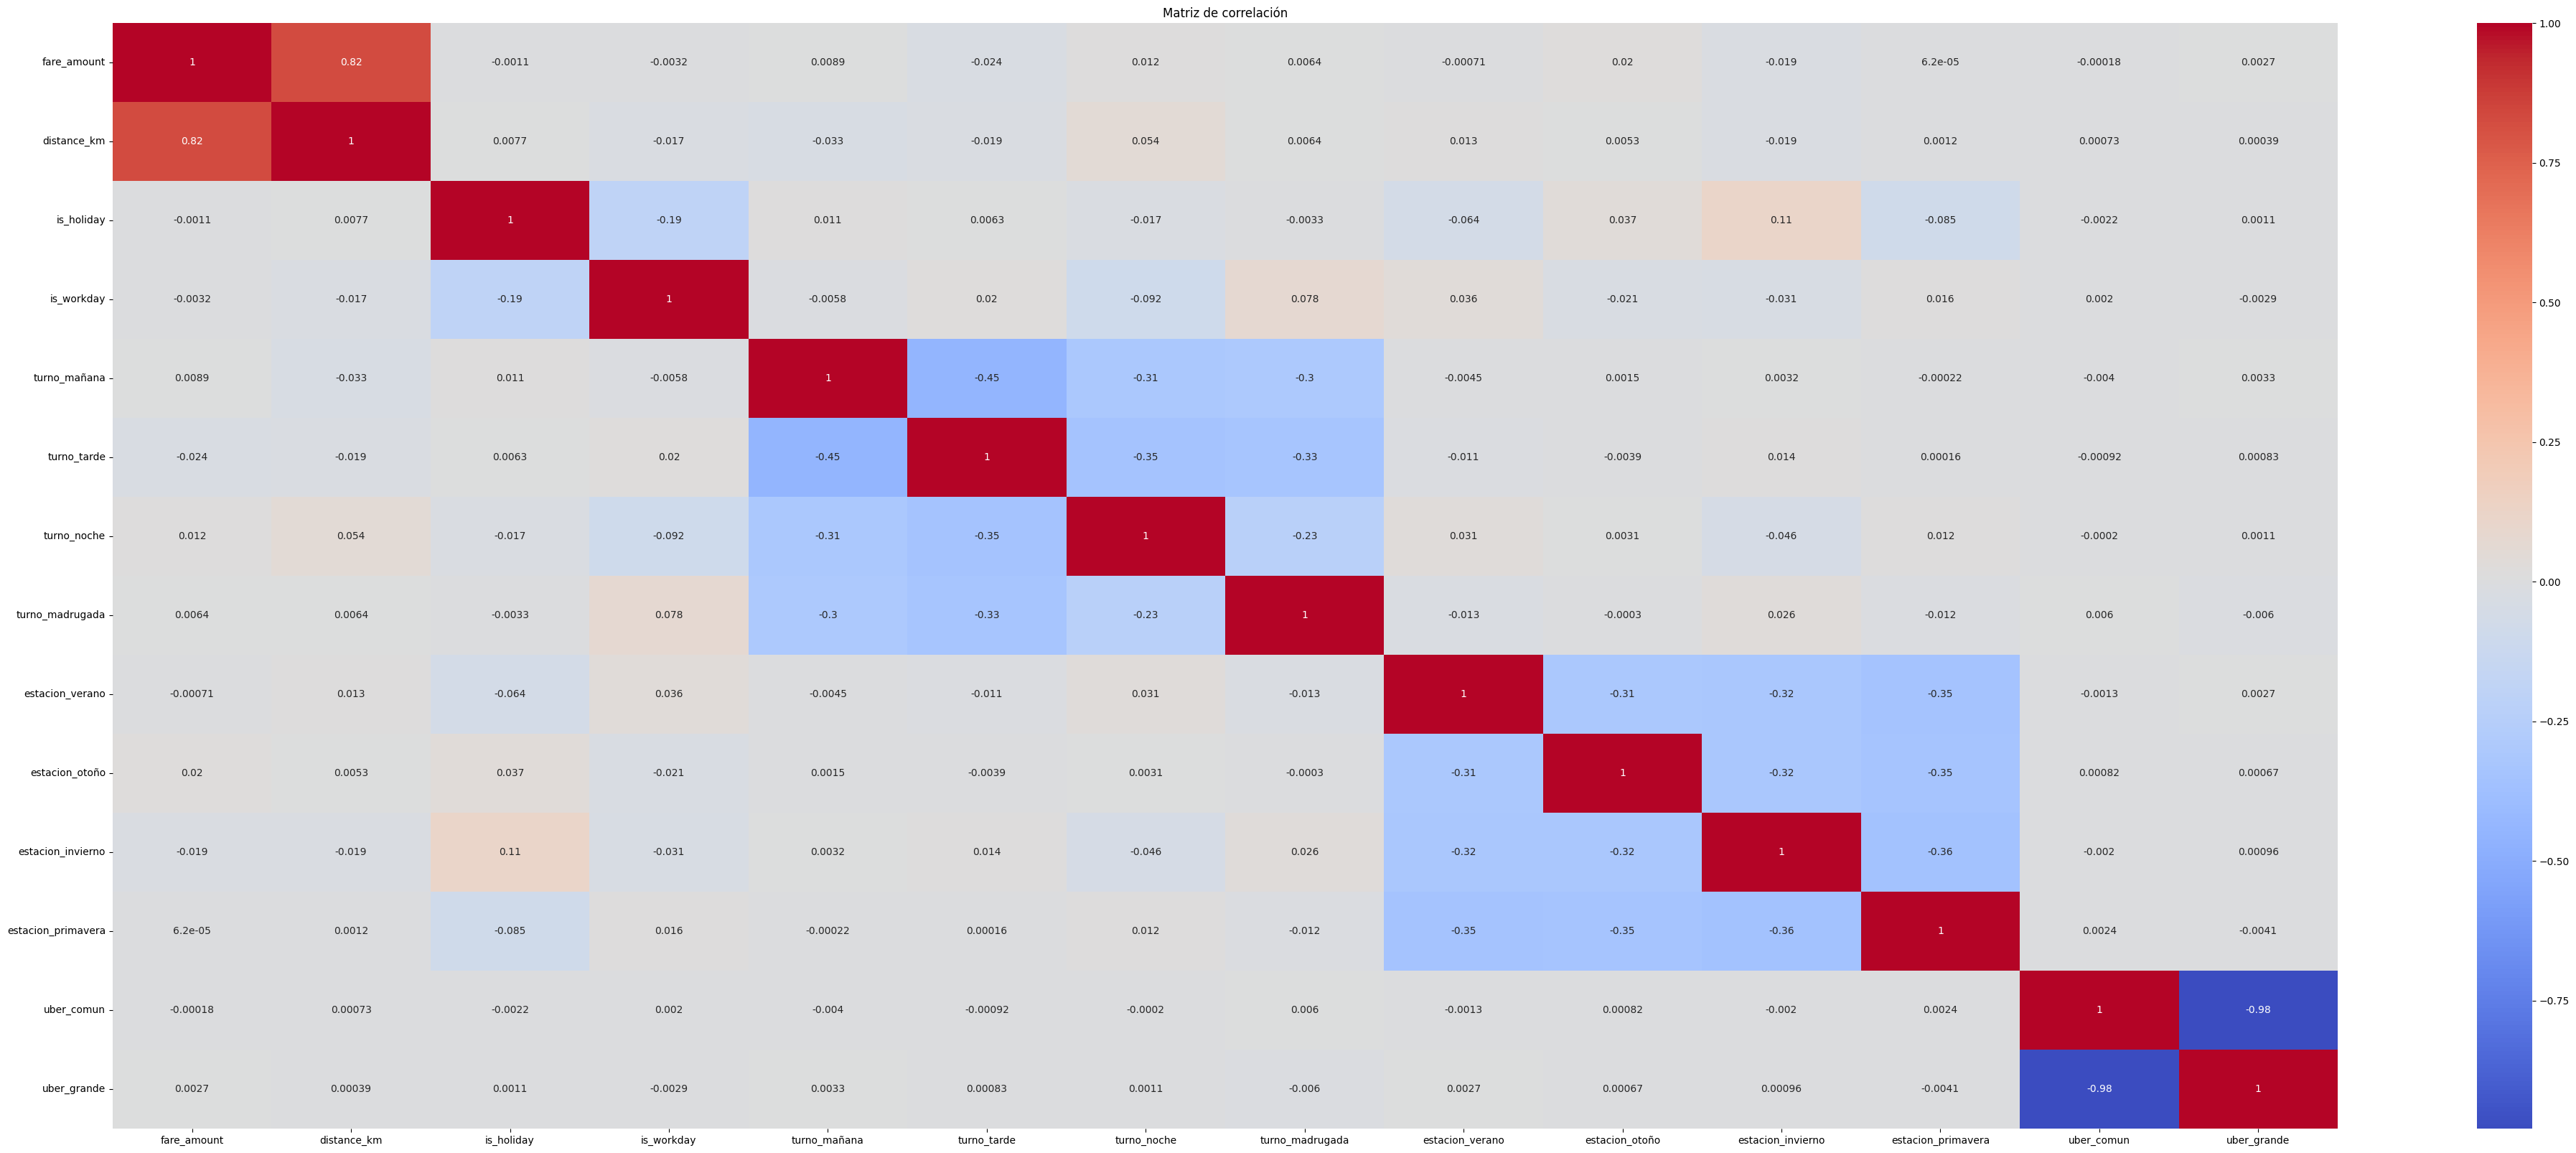

In [ ]:
# Supongamos que tus features están en un DataFrame "df"
corr = df_modelo.corr()

plt.figure(figsize=(50,20))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


distance_km           0.00079
is_holiday            0.00000
is_workday            0.00000
turno_mañana          0.00000
turno_tarde           0.00000
turno_noche           0.00000
turno_madrugada       0.00079
estacion_verano       0.00000
estacion_otoño        0.00000
estacion_invierno     0.00000
estacion_primavera    0.00079
uber_comun            1.00000
uber_grande           0.00000
Name: 170081, dtype: float64

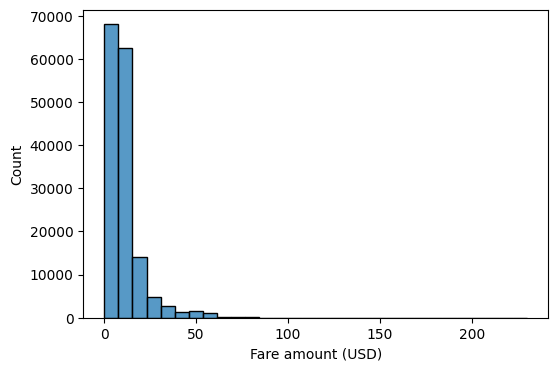

In [ ]:
##histograma de fare_amount
plt.figure(figsize=(6,4))   
sns.histplot(y_train, bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
##fare_amount mayores a 200
y_train[y_train > 200]
##ver fila del indice 170081
X_train.loc[170081]



ENTRENAMIENTO 
-------------

In [94]:

# Definimos columnas numéricas y categóricas
num_cols = ["distance_km", "turno_mañana", "turno_tarde", "turno_noche", "turno_madrugada", "estacion_verano", "estacion_otoño", "estacion_invierno", "estacion_primavera"]
cat_cols = ["is_holiday", "is_workday", "uber_comun", "uber_grande"]


# Preprocesador: escalar numéricas, dejar pasar dummies
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)  # deja las dummies como están
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [95]:
pipe_lr = make_pipeline(
    preprocessor,
    LinearRegression()
)

# Entrenamos el pipeline con training set
pipe_lr.fit(X=X_train, y = y_train)

# Predicciones sobre train y test
y_train_pred = pipe_lr.predict(X_train)
y_test_pred = pipe_lr.predict(X_test)

print("Entrenamiento:")
### RMSE calcular el RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_train, y_train_pred))

print("\nPrueba:")
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_test_pred))



Entrenamiento:
RMSE: 4.534541393938638
R²: 0.7672202520327486

Prueba:
RMSE: 5.323179598015119
R²: 0.7072790867868981


LINEAL
------

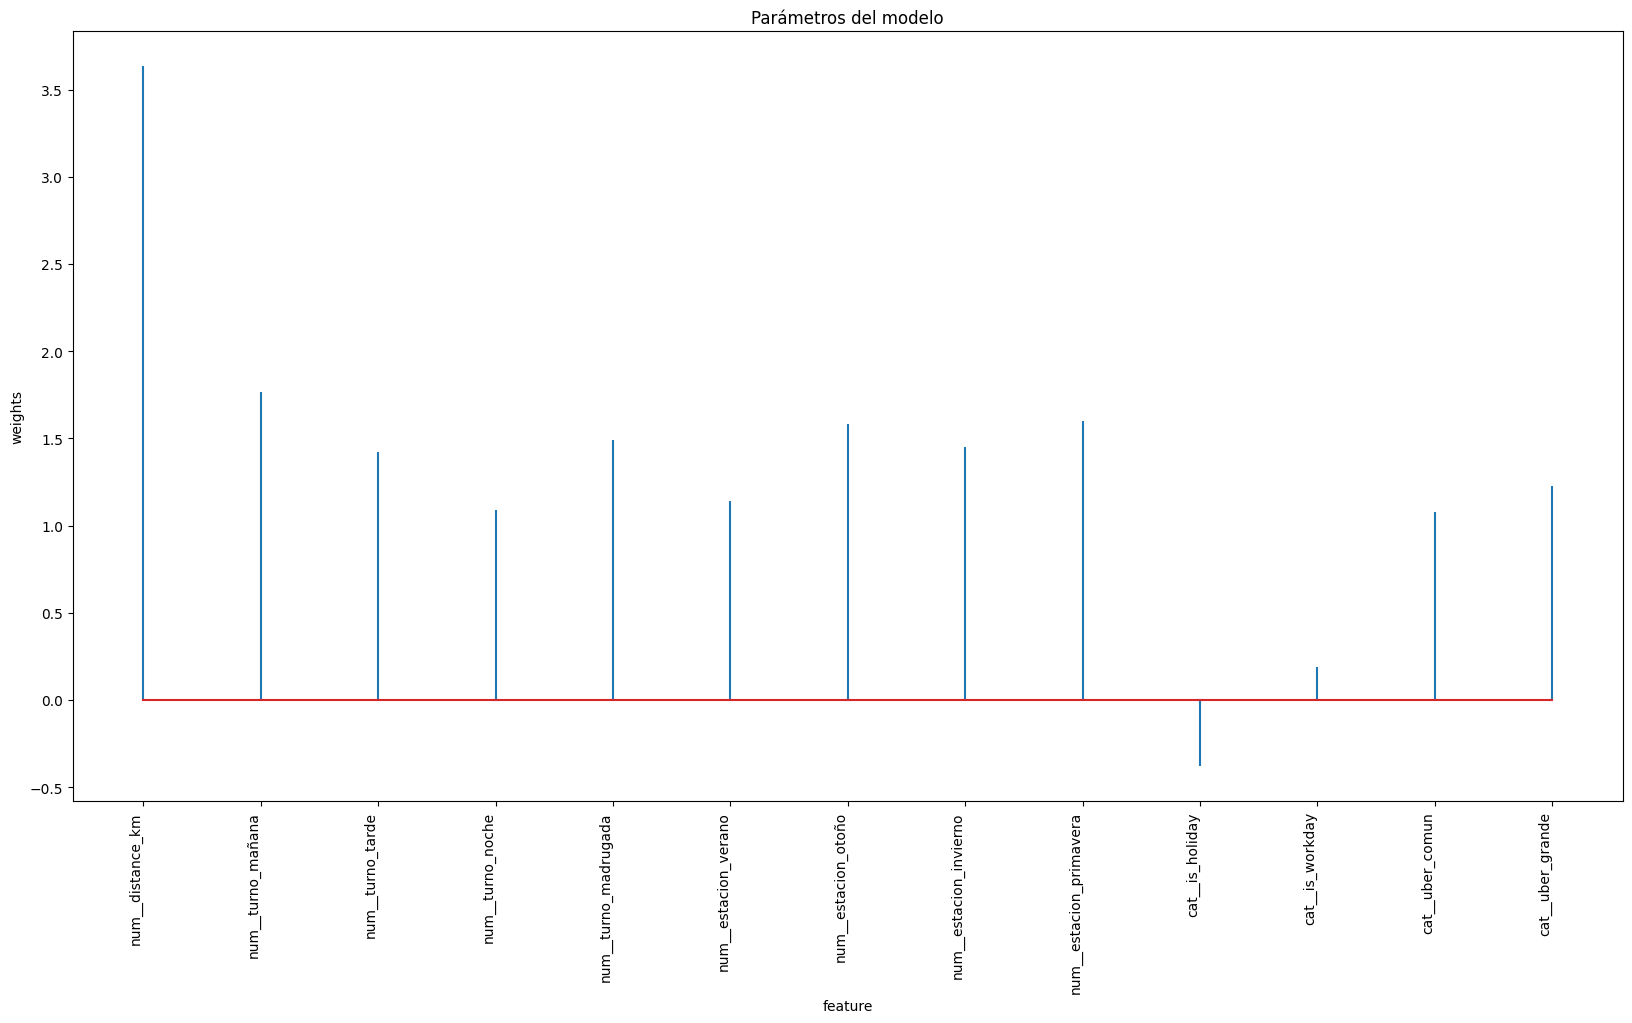

In [ ]:

preprocessor = pipe_lr.named_steps["columntransformer"]

feature_names = preprocessor.get_feature_names_out()

df_coeficientes = pd.DataFrame({
    "predictor": feature_names,
    "coef": pipe_lr.named_steps["linearregression"].coef_.flatten()
})

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo');

In [ ]:
# Predicciones test

predicciones_lnr = pipe_lr.predict(X=X_test)
predicciones_lnr = predicciones_lnr.flatten()
predicciones_lnr[:10]

array([ 7.14152294,  7.65042593,  9.41398432,  8.70448344, 13.1119577 ,
       17.04061107, 25.71778018,  7.33278806,  6.56490305, 13.30933894])

In [ ]:
rmse_ols = np.sqrt(mean_squared_error(y_test, predicciones_lnr))
print(f"El error (rmse) de test es: {rmse_ols}")



El error (rmse) de test es: 5.291529745156862


In [ ]:
from sklearn import metrics
R2 = metrics.r2_score(y_test, predicciones_lnr)
R2

0.7107495809254323

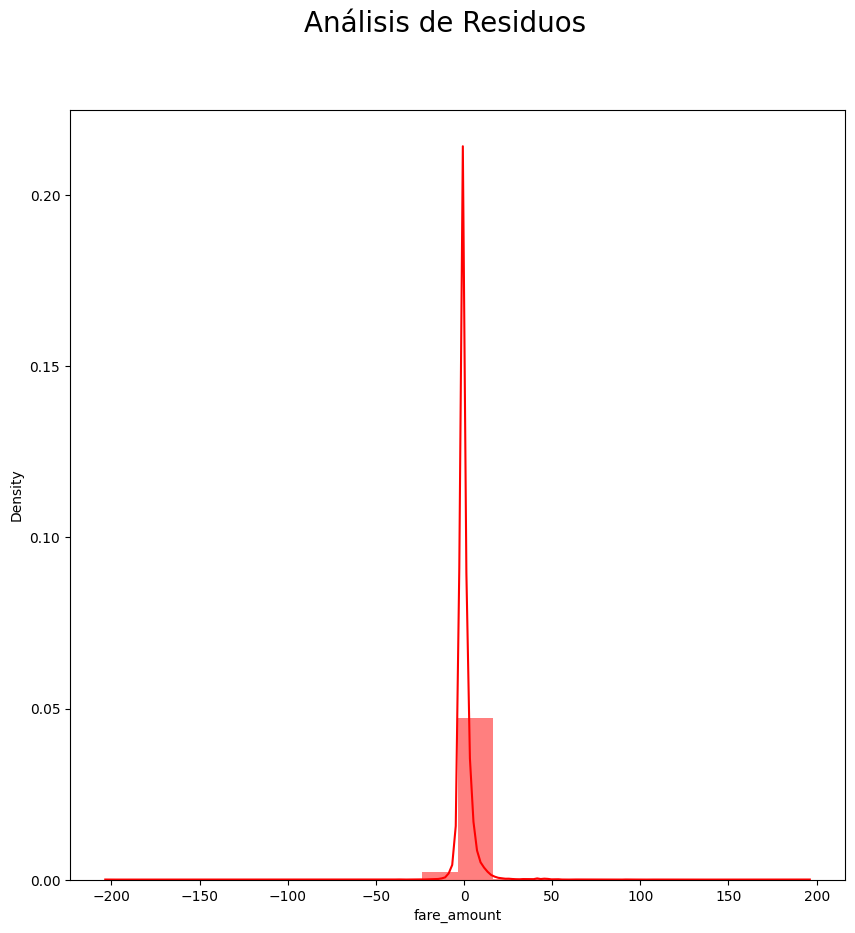

In [ ]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_lnr.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

Se detectaron 443 outliers
     y_real     y_pred    residuo
6      4.10  25.717780 -21.617780
23    57.54  41.079636  16.460364
104    3.30  30.700761 -27.400761
129   89.80  53.259064  36.540936
189   49.57   6.288775  43.281225


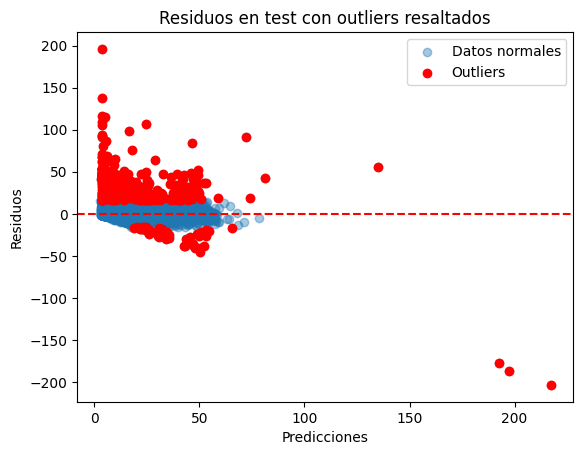

In [ ]:

# Suponiendo que y_test y y_pred ya son numpy arrays o pandas Series
y_real = np.ravel(y_test)   # convierte a array 1D
y_pred = np.ravel(y_test_pred)   # convierte a array 1D

residuos = y_real - y_pred

# Calcular media y desvío estándar
mean_res = np.mean(residuos)
std_res = np.std(residuos)

# Definir umbral (3 sigmas)
umbral = 3 * std_res

# Detectar outliers
outliers_mask = np.abs(residuos - mean_res) > umbral
outliers = pd.DataFrame({
    "y_real": y_real,
    "y_pred": y_pred,
    "residuo": residuos
})[outliers_mask]

print(f"Se detectaron {outliers.shape[0]} outliers")
print(outliers.head())

# Gráfico con outliers resaltados
plt.scatter(y_pred, residuos, alpha=0.4, label="Datos normales")
plt.scatter(outliers["y_pred"], outliers["residuo"], color="red", label="Outliers")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.legend()
plt.title("Residuos en test con outliers resaltados")
plt.show()


GRADIENTES 
----------

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)

In [ ]:
X_train_scaled = preprocessor.fit_transform(X_train)  # solo X_train
X_val_scaled   = preprocessor.transform(X_val)        # usar mismo scaler
X_test_scaled  = preprocessor.transform(X_test)

In [ ]:
X_train_scaled.shape, X_val_scaled.shape, X_test.shape

((137057, 13), (19580, 13), (39160, 13))

In [ ]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(137057,)
(19580,)
(39160,)


In [ ]:
y_train = y_train.values.reshape(-1,1)
y_val   = y_val.values.reshape(-1,1)
y_test  = y_test.values.reshape(-1,1)


### _GRADIENTE DESCENDIENTE_

Época 0/100 - Train RMSE: 14.5342 - Val RMSE: 14.4302
Época 10/100 - Train RMSE: 4.7572 - Val RMSE: 4.6460
Época 20/100 - Train RMSE: 4.6621 - Val RMSE: 4.5555
Época 30/100 - Train RMSE: 4.6081 - Val RMSE: 4.5027
Época 40/100 - Train RMSE: 4.5770 - Val RMSE: 4.4724
Época 50/100 - Train RMSE: 4.5588 - Val RMSE: 4.4549
Época 60/100 - Train RMSE: 4.5481 - Val RMSE: 4.4448
Época 70/100 - Train RMSE: 4.5417 - Val RMSE: 4.4390
Época 80/100 - Train RMSE: 4.5379 - Val RMSE: 4.4356
Época 90/100 - Train RMSE: 4.5356 - Val RMSE: 4.4336


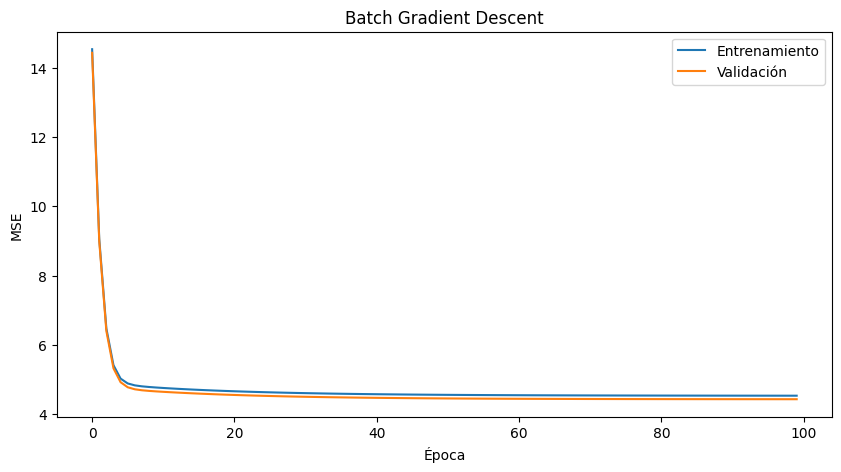

In [ ]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.1, epochs=100, schedule=False):
    n, m = X_train.shape
    o = X_val.shape[0]

    # Agregar columna de unos (bias)
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val   = np.hstack((np.ones((o, 1)), X_val))

    # Asegurar vectores columna
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    # Inicializar pesos en cero
    W = np.zeros((m+1, 1))

    train_errors = []
    val_errors = []

    for ep in range(epochs):
        # Predicción entrenamiento
        pred_train = X_train @ W
        error_train = y_train - pred_train

        # MSE entrenamiento
        train_rmse = np.sqrt(np.mean(error_train**2))
        train_errors.append(train_rmse)

        # Predicción validación
        pred_val = X_val @ W
        error_val = y_val - pred_val

        # RMSE validación
        val_rmse = np.sqrt(np.mean(error_val**2))
        val_errors.append(val_rmse)


        # Gradiente vectorizado: -(2/n) Xᵀ (y - XW)
        grad = -(2/n) * (X_train.T @ error_train)

        # Learning rate con schedule opcional
        lr_t = lr / np.sqrt(ep+1) if schedule else lr
        W -= lr_t * grad

        if ep % 10 == 0:
            print(f"Época {ep}/{epochs} - Train RMSE: {train_rmse:.4f} - Val RMSE: {val_rmse:.4f}")

    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(val_errors, label='Validación')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Batch Gradient Descent')
    plt.show()

    return W



W_batch = gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.1, epochs=100)



### _GRADIENTE ESTOCÁSTICO_

Época 1/20 - Train MSE: 7.5358 - Test MSE: 7.4737
Época 2/20 - Train MSE: 6.2954 - Test MSE: 6.2309
Época 3/20 - Train MSE: 5.6982 - Test MSE: 5.6270
Época 4/20 - Train MSE: 5.4106 - Test MSE: 5.3302
Época 5/20 - Train MSE: 5.2753 - Test MSE: 5.1847
Época 6/20 - Train MSE: 5.1334 - Test MSE: 5.0357
Época 7/20 - Train MSE: 5.0417 - Test MSE: 4.9382
Época 8/20 - Train MSE: 4.9937 - Test MSE: 4.8775
Época 9/20 - Train MSE: 4.9379 - Test MSE: 4.8249
Época 10/20 - Train MSE: 4.9015 - Test MSE: 4.7812
Época 11/20 - Train MSE: 4.8751 - Test MSE: 4.7566
Época 12/20 - Train MSE: 4.8752 - Test MSE: 4.7731
Época 13/20 - Train MSE: 4.8506 - Test MSE: 4.7457
Época 14/20 - Train MSE: 4.8308 - Test MSE: 4.7241
Época 15/20 - Train MSE: 4.8174 - Test MSE: 4.7058
Época 16/20 - Train MSE: 4.8077 - Test MSE: 4.6997
Época 17/20 - Train MSE: 4.8077 - Test MSE: 4.7087
Época 18/20 - Train MSE: 4.7982 - Test MSE: 4.6988
Época 19/20 - Train MSE: 4.7973 - Test MSE: 4.7047
Época 20/20 - Train MSE: 4.7939 - Test M

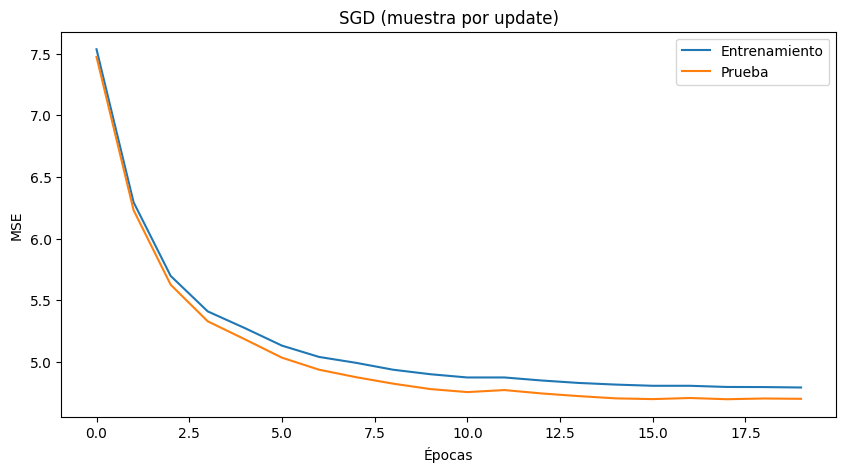

In [ ]:
def stochastic_gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.001, epochs=20, updates_per_epoch=10000, schedule=True
):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.zeros((m + 1, 1))  # pesos iniciales

    train_errors, test_errors = [], []
    t = 0  # contador de updates totales

    for ep in range(epochs):
        # indices aleatorios para elegir muestras
        idx = np.random.permutation(n)
        k = min(updates_per_epoch, n)   # límite de updates por época
        pick = idx[:k]

        for j in pick:
            x_sample = X_train[j:j+1]   # (1, m+1)
            y_sample = y_train[j:j+1]   # (1, 1)

            prediction = x_sample @ W
            error = y_sample - prediction

            gradient = -2 * (x_sample.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores por época
        train_pred = X_train @ W
        train_rmse = np.sqrt(np.mean((y_train - train_pred)**2))
        train_errors.append(train_rmse)

        test_pred = X_test @ W
        test_rmse = np.sqrt(np.mean((y_test - test_pred)**2))
        test_errors.append(test_rmse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_rmse:.4f} - Test MSE: {test_rmse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('SGD (muestra por update)')
    plt.show()

    return W


# Ejecutar SGD
W_sgd = stochastic_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=20)


### _MINI BATCH_

Época 1/200 - Train MSE: 5.0314 - Test MSE: 4.9321
Época 2/200 - Train MSE: 4.8251 - Test MSE: 4.7145
Época 3/200 - Train MSE: 4.7790 - Test MSE: 4.6681
Época 4/200 - Train MSE: 4.7562 - Test MSE: 4.6462
Época 5/200 - Train MSE: 4.7403 - Test MSE: 4.6308
Época 6/200 - Train MSE: 4.7276 - Test MSE: 4.6183
Época 7/200 - Train MSE: 4.7167 - Test MSE: 4.6078
Época 8/200 - Train MSE: 4.7074 - Test MSE: 4.5983
Época 9/200 - Train MSE: 4.6994 - Test MSE: 4.5876
Época 10/200 - Train MSE: 4.6917 - Test MSE: 4.5811
Época 11/200 - Train MSE: 4.6849 - Test MSE: 4.5748
Época 12/200 - Train MSE: 4.6786 - Test MSE: 4.5690
Época 13/200 - Train MSE: 4.6729 - Test MSE: 4.5641
Época 14/200 - Train MSE: 4.6676 - Test MSE: 4.5592
Época 15/200 - Train MSE: 4.6627 - Test MSE: 4.5547
Época 16/200 - Train MSE: 4.6582 - Test MSE: 4.5508
Época 17/200 - Train MSE: 4.6539 - Test MSE: 4.5467
Época 18/200 - Train MSE: 4.6499 - Test MSE: 4.5428
Época 19/200 - Train MSE: 4.6461 - Test MSE: 4.5395
Época 20/200 - Train 

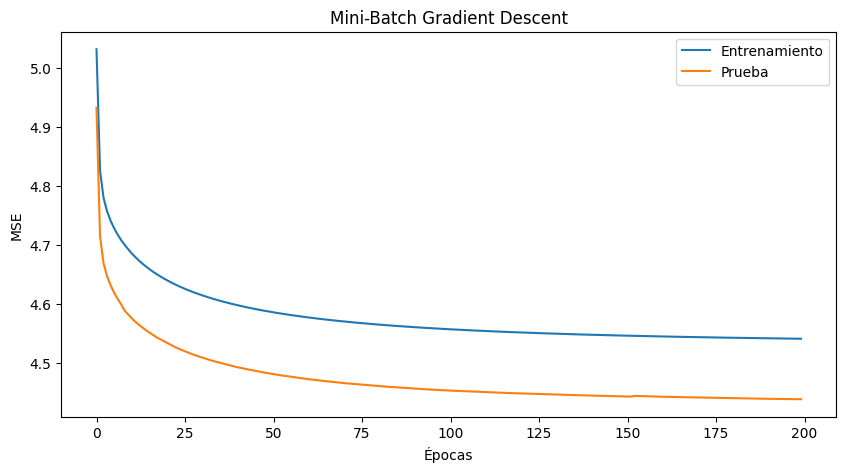

In [ ]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test,
                                lr=0.01, epochs=20, batch_size=32, schedule=True):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # Asegurar que y sean vectores columna
    y_train = y_train.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    # Inicializar pesos
    W = np.zeros((m + 1, 1))

    train_errors, test_errors = [], []
    t = 0  # contador de updates

    for ep in range(epochs):
        # Permutar aleatoriamente
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        # Recorrer en lotes
        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size]
            y_batch = y_train[j:j+batch_size]

            prediction = x_batch @ W
            error = y_batch - prediction

            gradient = -(2 / len(x_batch)) * (x_batch.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores globales por época
        train_rmse = np.sqrt(np.mean((y_train - (X_train @ W))**2))
        test_rmse  = np.sqrt(np.mean((y_test  - (X_test  @ W))**2))

        train_errors.append(train_rmse)
        test_errors.append(test_rmse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_rmse:.4f} - Test MSE: {test_rmse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Mini-Batch Gradient Descent')
    plt.show()

    return W


W_mini = mini_batch_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.01, epochs=200, batch_size=200)



REGULARIZACIÓN
--------------


### _RIDGE_

In [ ]:

modelo_ridge = RidgeCV(
    alphas = np.logspace(-4, 4, 100),
    cv=5,
    fit_intercept=True,
)
modelo_ridge.fit(X_train_scaled, y_train)

# Evaluar en el set de validación
y_val_pred = modelo_ridge.predict(X_val_scaled)
mse_val = mean_squared_error(y_val, y_val_pred)
print("MSE en validación:", mse_val)


MSE en validación: 19.61668458124807


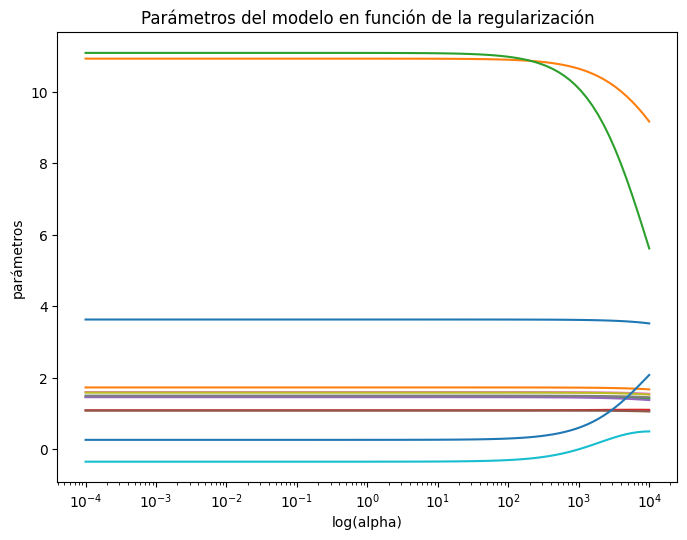

In [ ]:

alphas = modelo_ridge.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización');
plt.axis('tight')
plt.show()

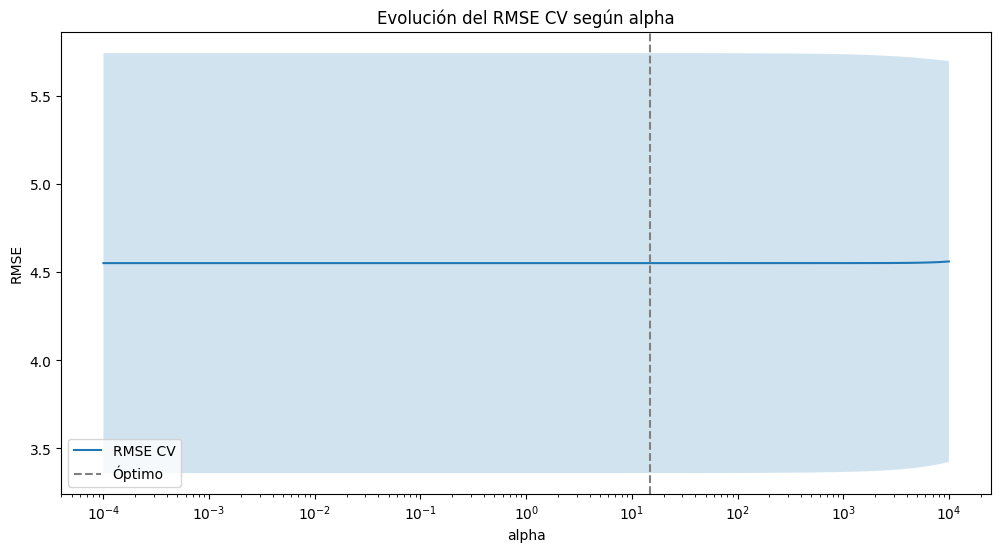

In [ ]:
alphas = np.logspace(-4, 4, 100)
rmse_mean = []
rmse_std  = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    
    # cross_val_score devuelve score (por defecto R^2), usamos scoring="neg_mean_squared_error"
    mse_scores = -cross_val_score(ridge, X_train_scaled, y_train,
                                  cv=kf,
                                  scoring="neg_mean_squared_error")
    
    rmse_mean.append(np.sqrt(mse_scores.mean()))
    rmse_std.append(np.sqrt(mse_scores.std()))

rmse_mean = np.array(rmse_mean)
rmse_std  = np.array(rmse_std)

# Alpha óptimo
optimo = alphas[np.argmin(rmse_mean)]

# Gráfico
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(alphas, rmse_mean, label="RMSE CV")
ax.fill_between(alphas, rmse_mean - rmse_std, rmse_mean + rmse_std, alpha=0.2)
ax.axvline(optimo, linestyle="--", color="gray", label="Óptimo")
ax.set_xscale('log')
ax.set_xlabel("alpha")
ax.set_ylabel("RMSE")
ax.set_title("Evolución del RMSE CV según alpha")
ax.legend()
plt.show()

In [ ]:
print(f"Mejor valor de alpha encontrado: {modelo_ridge.alpha_}")

Mejor valor de alpha encontrado: 21.544346900318867


In [ ]:
predicciones_ridge = modelo_ridge.predict(X = X_test_scaled)
predicciones_ridge = predicciones_ridge.flatten()
predicciones_ridge[:10]

array([ 7.16132015,  7.57977763,  9.40736033,  8.78431616, 13.15869143,
       17.12156618, 25.84876077,  7.32460558,  6.53690377, 13.12424376])

In [ ]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, predicciones_ridge))
print(f"El error (rmse) de test es: {rmse_ridge}")

El error (rmse) de test es: 5.296288009836877


In [ ]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, predicciones_ridge)
R2

0.7102291458403731

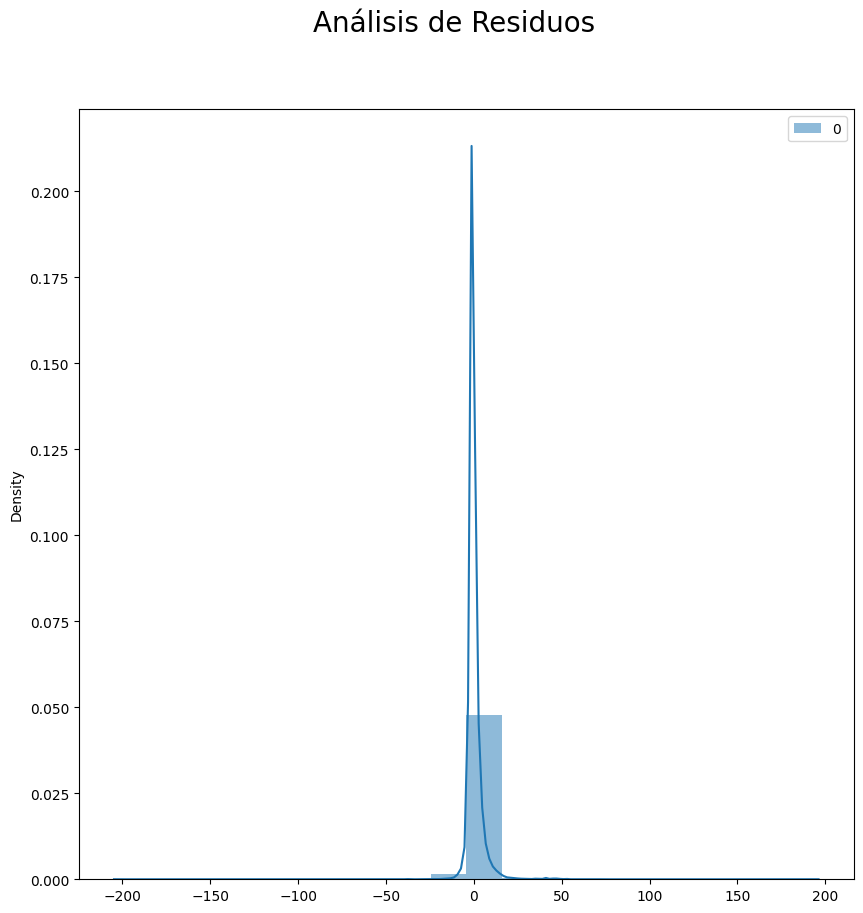

In [ ]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_ridge.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

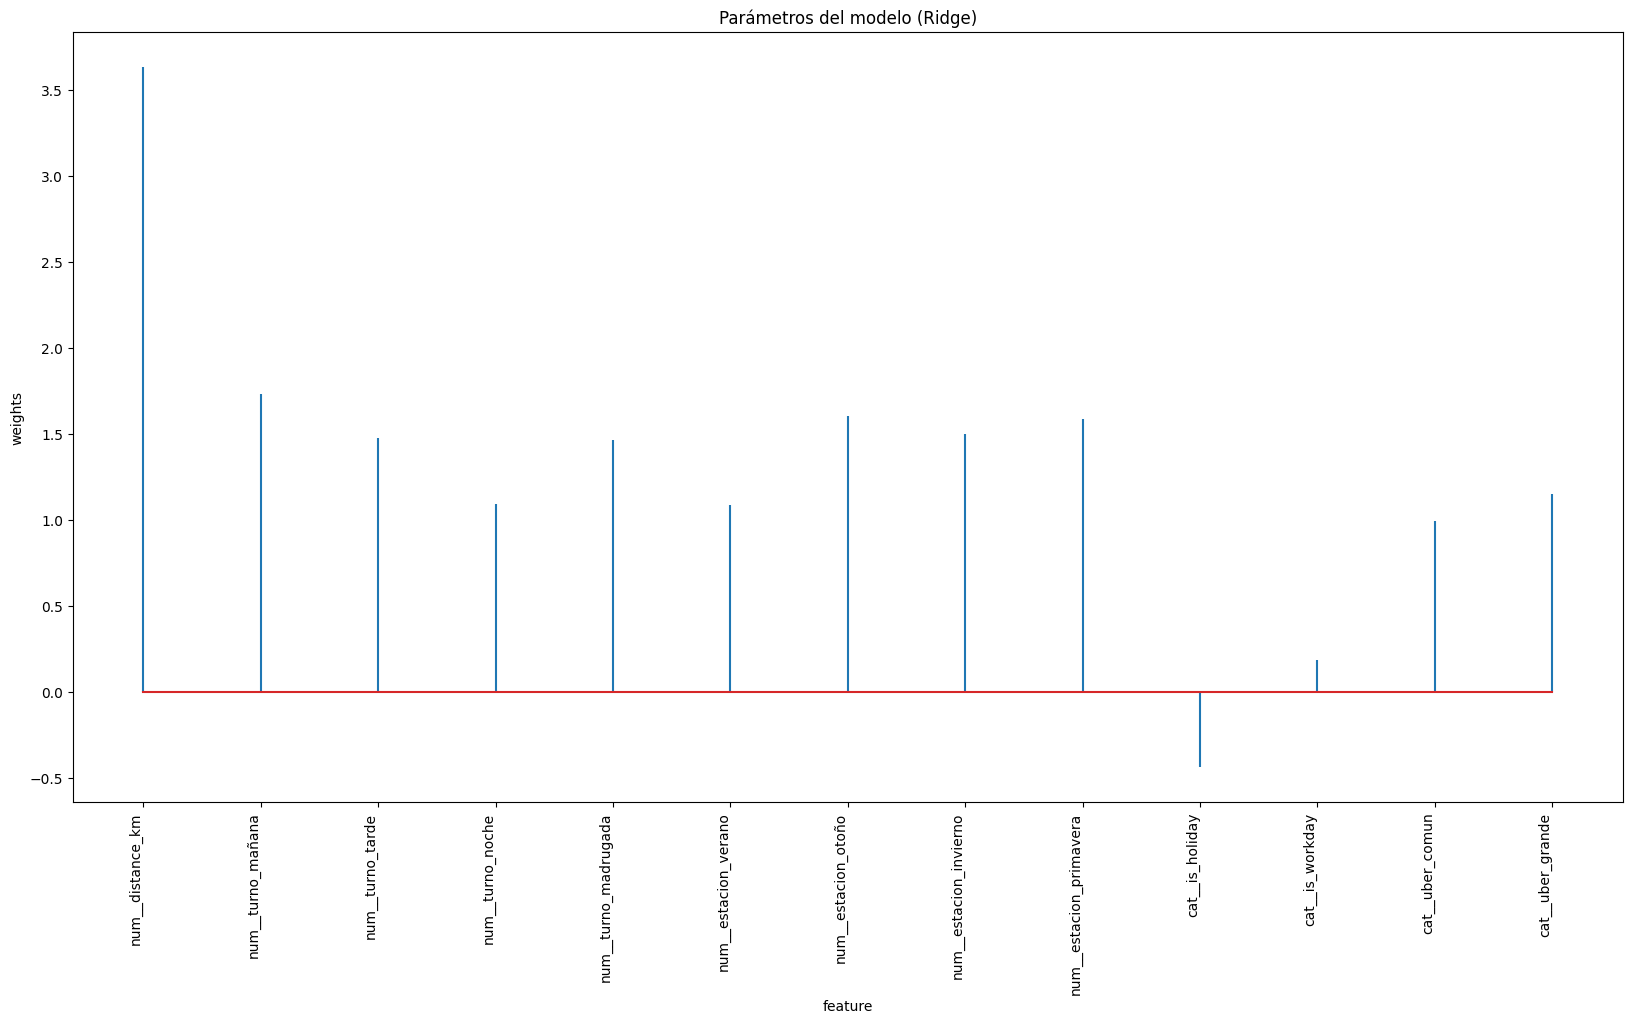

In [ ]:
# Coeficientes del modelo Lasso
df_coeficientes = pd.DataFrame({
    "predictor": preprocessor.get_feature_names_out(),
    "coef": modelo_ridge.coef_.flatten()
})

# Gráfico
fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes["predictor"], df_coeficientes["coef"], markerfmt=" ")
plt.xticks(rotation=90, ha="right", size=10)
ax.set_xlabel("feature")
ax.set_ylabel("weights")
ax.set_title("Parámetros del modelo (Ridge)")
plt.show()

### _LASSO_

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.462e+04, tolerance: 1.215e+03
  model = cd_fast.enet_coordinate_descent(


Mejor alpha encontrado: 0.0001


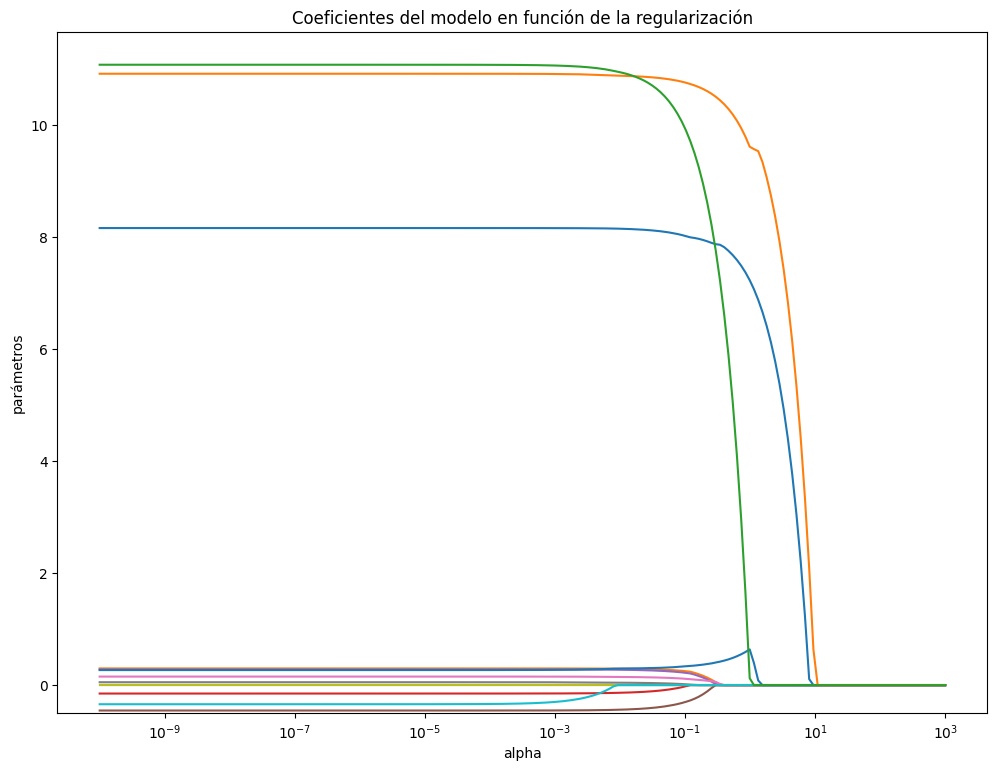

In [ ]:
from sklearn.linear_model import lasso_path
modelo = LassoCV(alphas = np.logspace(-4, 4, 100), cv=10)
modelo.fit(X_train_scaled, y_train.flatten())           #TODAVIA ME FALTA REPASAR DONDE VA X_VAL_SCALED
print("Mejor alpha encontrado:", modelo.alpha_)

# Usar lasso_path para obtener coeficientes en un rango de alphas
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train.flatten(), alphas=np.logspace(-10, 3, 200))

# Graficar
fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas_lasso, coefs_lasso.T)   # transponer para graficar cada coef
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()




In [ ]:
"""
alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº parámetros')
ax.set_title('Features incluidas en función de la regularización')
"""

"\nalphas = modelo.alphas_\nn_predictores = []\n\nfor alpha in alphas:\n    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)\n    modelo_temp.fit(X_train_scaled, y_train)\n    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)\n    n_predictores.append(coef_no_cero)\n\nfig, ax = plt.subplots(figsize=(15, 5))\nax.plot(alphas, n_predictores)\nax.set_xscale('log')\nax.set_ylim([-0.5,None])\nax.set_xlabel('alpha')\nax.set_ylabel('nº parámetros')\nax.set_title('Features incluidas en función de la regularización')\n"

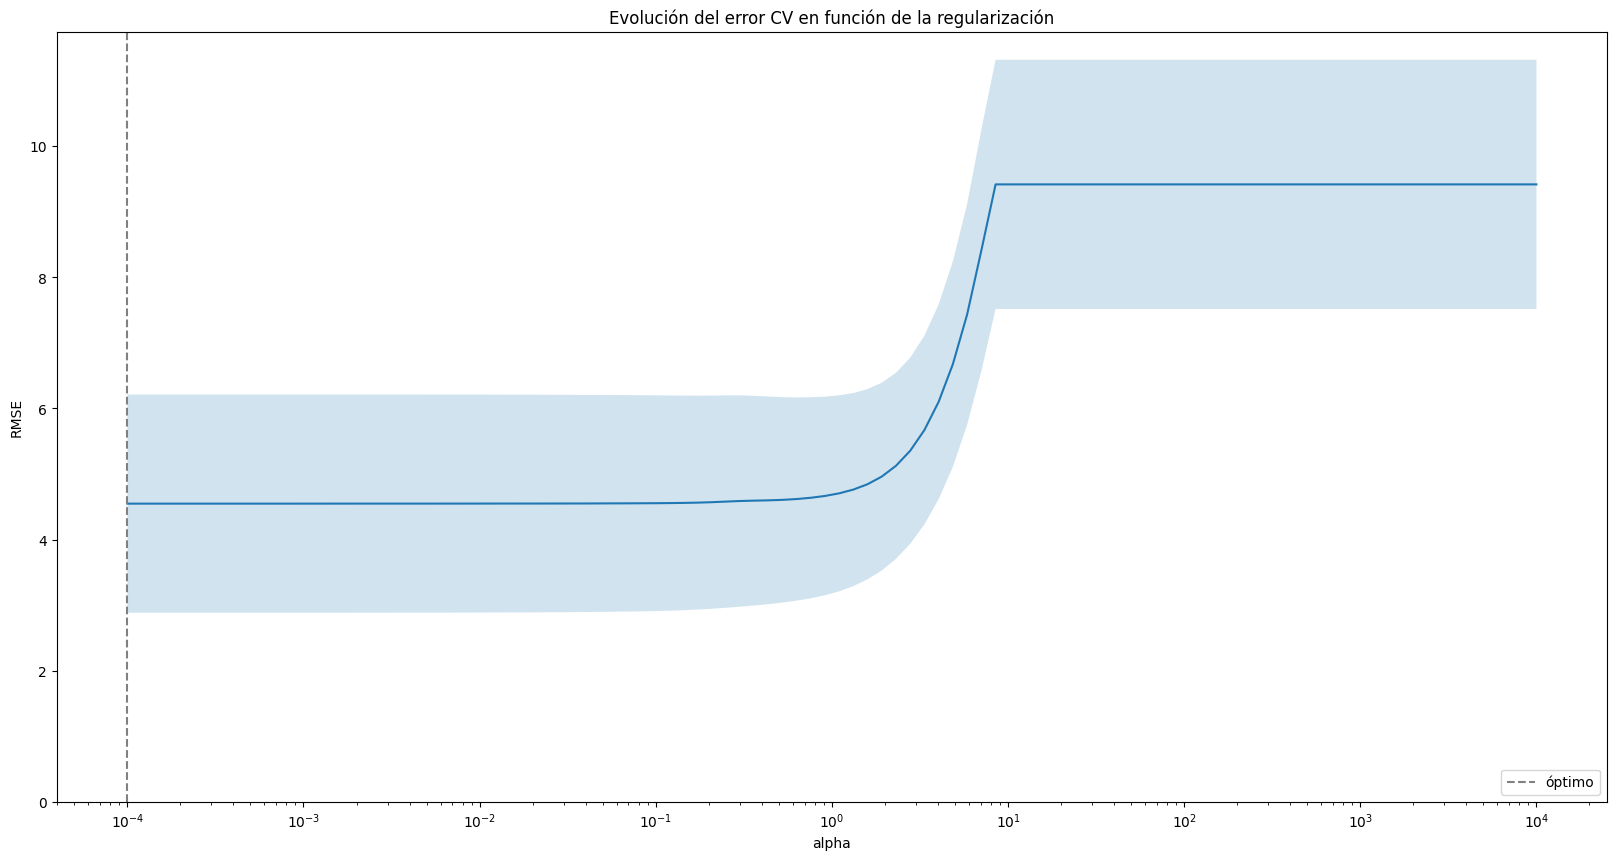

In [ ]:
# Evolución del error de validación cruzada en función de alpha

mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
optimo       = modelo.alphas_[np.argmin(rmse_cv)]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)

ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

In [ ]:
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 0.0001


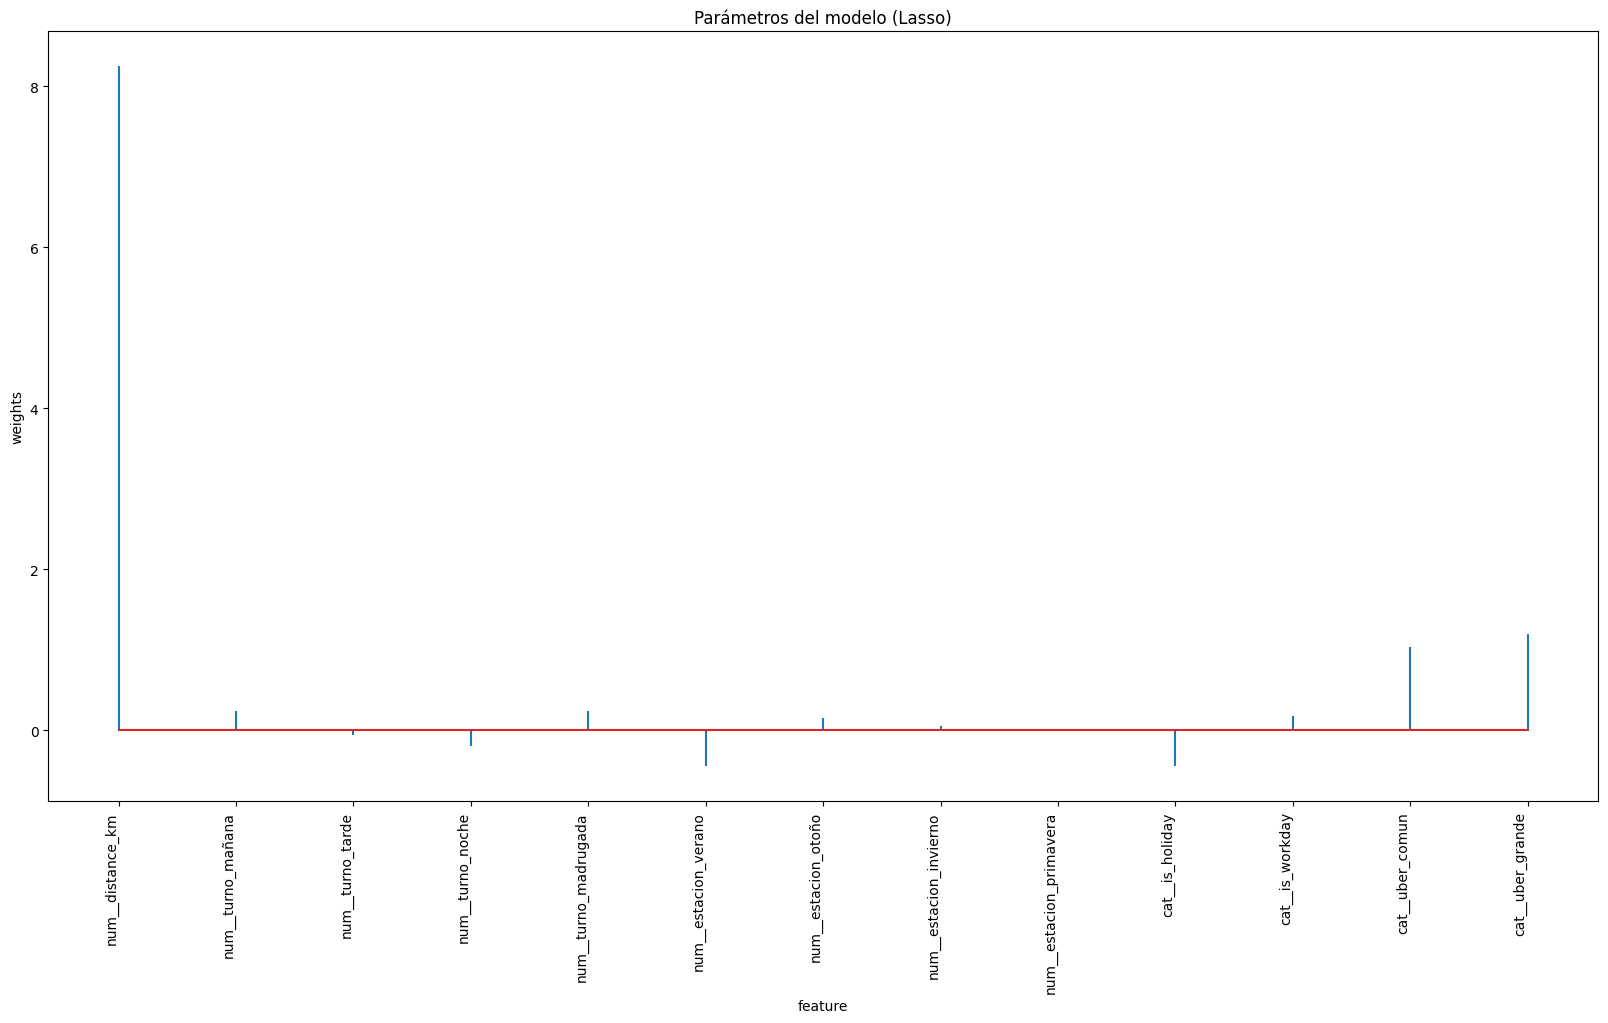

In [ ]:
# Coeficientes del modelo Lasso
df_coeficientes = pd.DataFrame({
    "predictor": preprocessor.get_feature_names_out(),
    "coef": modelo.coef_.flatten()
})

# Gráfico
fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes["predictor"], df_coeficientes["coef"], markerfmt=" ")
plt.xticks(rotation=90, ha="right", size=10)
ax.set_xlabel("feature")
ax.set_ylabel("weights")
ax.set_title("Parámetros del modelo (Lasso)")
plt.show()

In [ ]:
predicciones_lasso = modelo.predict(X=X_test_scaled) #Hacerlo con el x_val_scaled para ver el error en validación?
predicciones_lasso = predicciones_lasso.flatten()
predicciones_lasso[:10]

array([ 7.16109304,  7.57947331,  9.40816307,  8.78429043, 13.15901528,
       17.12187393, 25.84961961,  7.32460993,  6.53654394, 13.12447612])

In [ ]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, predicciones_lasso))
print(f"El error (rmse) de test es: {rmse_lasso}")

El error (rmse) de test es: 5.296265440218472


In [ ]:
R2 = metrics.r2_score(y_test, predicciones_lasso)
R2

0.710231615495972

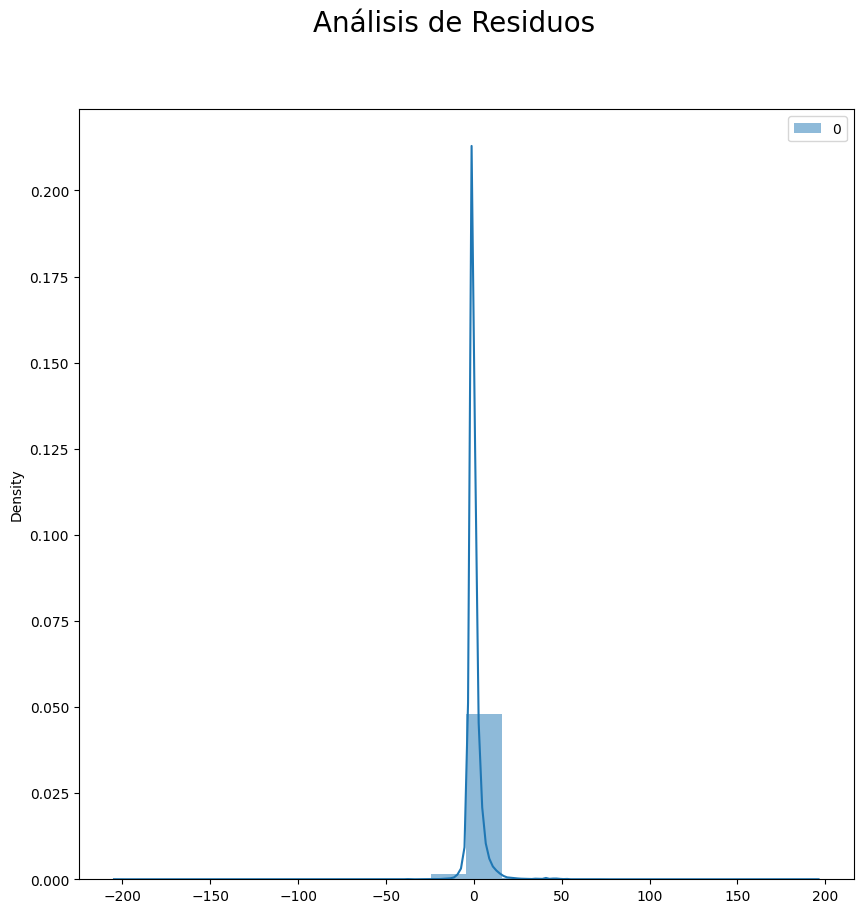

In [ ]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones_lasso.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

### _ELASTIC NET_


In [ ]:
modelo_elast = ElasticNetCV(
            l1_ratio        = [0.1, 0.5, 0.9], #Tuve que cambiar esto del original
            alphas          = np.logspace(-4, 2, 100), #Esto tambien
            cv              = 5,
            max_iter        = 10000
         )
_ = modelo_elast.fit(X = X_train_scaled, y = y_train.flatten())


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.875e+05, tolerance: 1.215e+03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Predicciones con los mejores parámetros
pred = modelo_elast.predict(X_val_scaled)

# RMSE
rmse_elastic = np.sqrt(mean_squared_error(y_val, pred))
print("Alpha óptimo:", modelo_elast.alpha_)
print("L1_ratio óptimo:", modelo_elast.l1_ratio_)
print("RMSE en validación:", rmse)


Alpha óptimo: 0.0001747528400007683
L1_ratio óptimo: 0.1
RMSE en validación: 5.291529745156862


In [ ]:
# Error medio de las 10 particiones por cada valor de alpha y l1_ratio 
mean_error_cv = modelo_elast.mse_path_.mean(axis =2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha) se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [modelo_elast.l1_ratio, modelo_elast.alphas_],
                                    names     = ['l1_ratio', 'modelo.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
95,0.1,0.000175,20.671021,4.546539
94,0.1,0.000201,20.671021,4.546539
96,0.1,0.000152,20.671022,4.546540
97,0.1,0.000132,20.671023,4.546540
93,0.1,0.000231,20.671023,4.546540
...,...,...,...,...
204,0.9,57.223677,88.663898,9.416151
205,0.9,49.770236,88.663898,9.416151
206,0.9,43.287613,88.663898,9.416151
101,0.5,86.974900,88.663898,9.416151


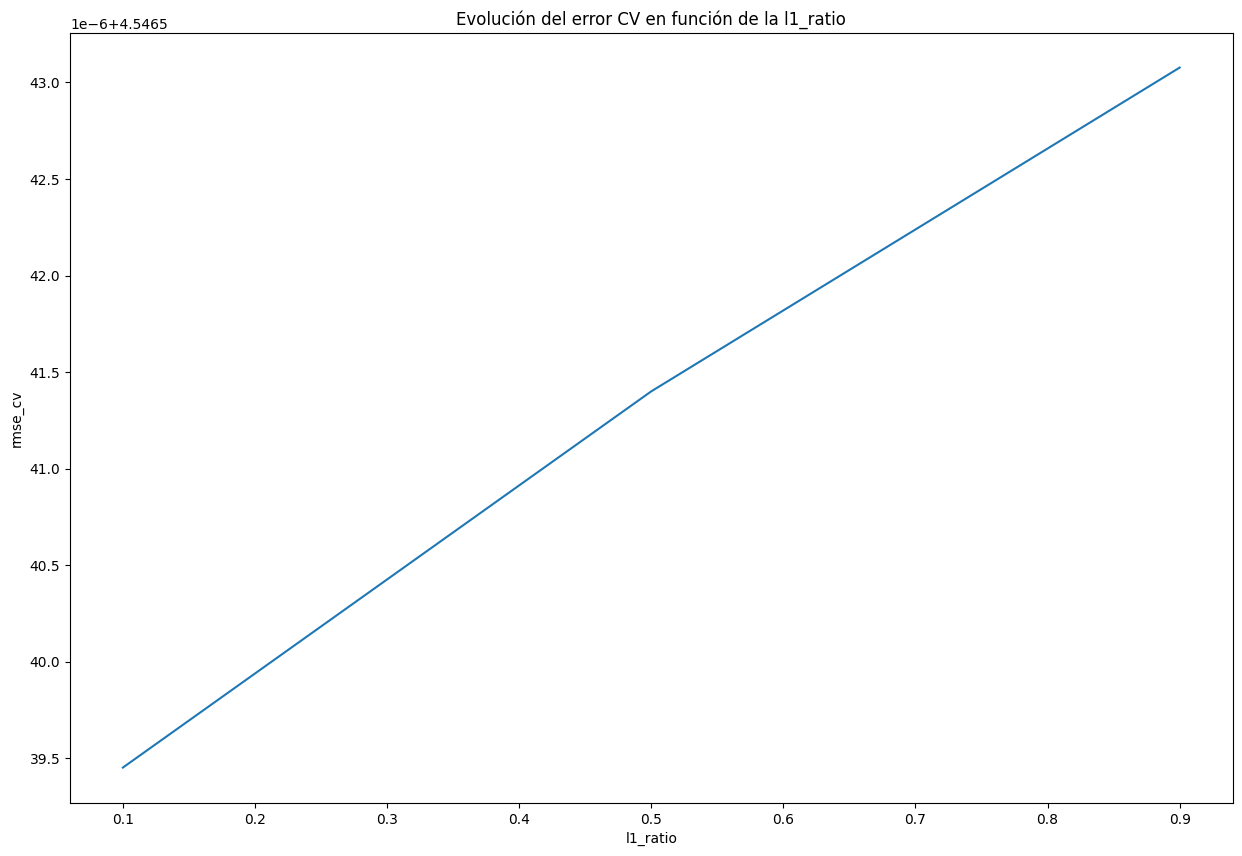

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

In [ ]:
print("Mejor alpha:", modelo_elast.alpha_)
print("Mejor l1_ratio:", modelo_elast.l1_ratio_)

Mejor alpha: 0.0001747528400007683
Mejor l1_ratio: 0.1


In [ ]:
pred_val = modelo_elast.predict(X_test_scaled)
pred_val = pred_val.flatten()

In [ ]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, pred_val)
R2

0.7102287866001766

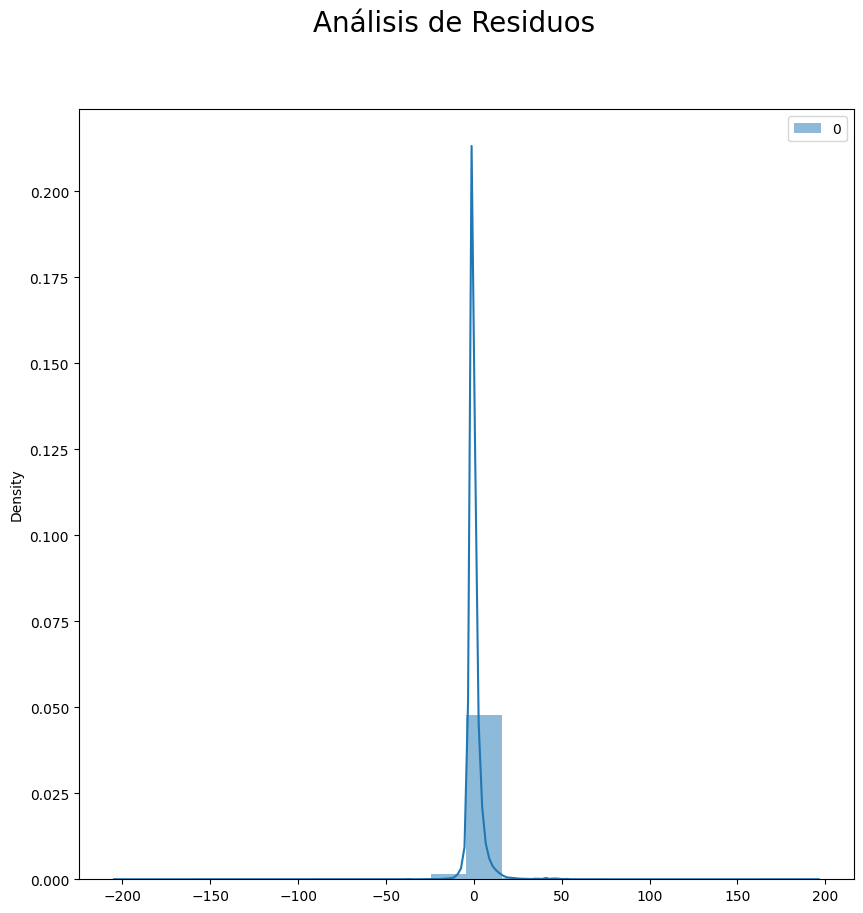

In [ ]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - pred_val.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

### _Comparación de Modelos_

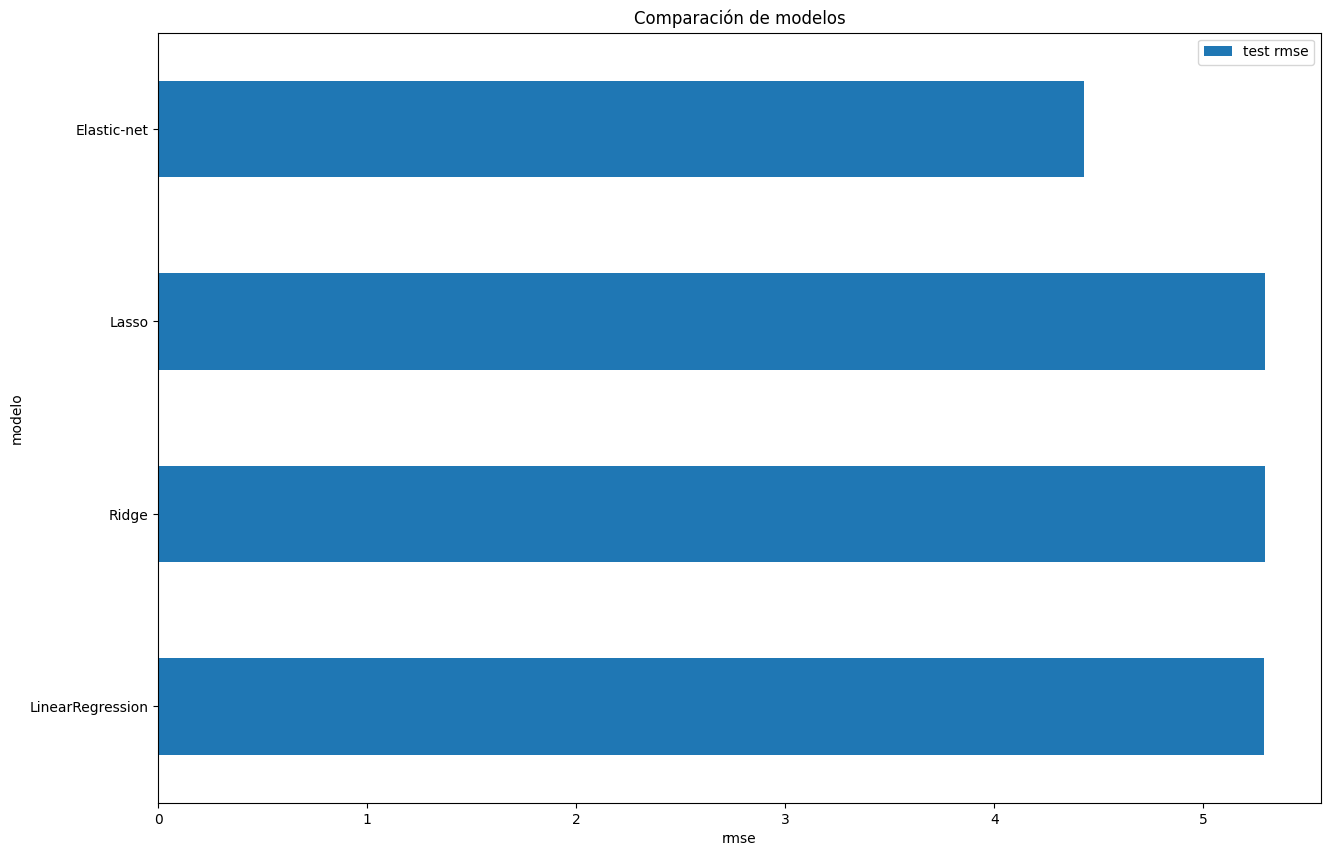

In [ ]:
df_comparacion = pd.DataFrame({
                    'modelo': ['LinearRegression', 'Ridge', 'Lasso', 'Elastic-net'],
                    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
                 })

fig, ax = plt.subplots(figsize=(15, 10))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos');